In [1]:
import glob
import os
import tqdm

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
# import mpl_toolkits.axes_grid1
import japanize_matplotlib

import astropy
import astropy.io.fits
import astropy.units as u
import astroquery.vizier
# from astropy.wcs import WCS
from spectral_cube import SpectralCube
import pylab

pylab.rcParams['font.family'] = 'serif'
pylab.rcParams['lines.linewidth'] = 0.5
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = 15
pylab.rcParams["xtick.direction"] = "in"
pylab.rcParams["ytick.direction"] = "in"

In [2]:
import sys
# sys.path.append('/home/elmegreen/galactic_bubble/photoutils/')
from processing import norm_res, normalize_rp, remove_nan, conv, data_view_rectangl, resize
from utils.ssd_model import nm_suppression

# sys.path.append('/home/elmegreen/jupyter/research/Bubble_Analysis/CO_SpitzerBubble/All_Bubble_Analysis/Analysis')
from Function_to_Detect_peak import find_verified_peak, _detect_and_characterize_peak, find_velocity_from_catalog, _check_signal_at_channel, gaussian_filter
from detect_rough_tools import extract_spectral, make_spitzer_fits, load_spitzer_fits, make_momont012_map

In [3]:
viz = astroquery.vizier.Vizier(columns=["*"])
viz.ROW_LIMIT = -1
bub_velocity_table = viz.query_constraints(catalog="J/MNRAS/438/426")[0].to_pandas()

# GLONを0-360度の範囲に正規化
bub_velocity_table['GLON'] = bub_velocity_table['GLON'] % 360
bub_velocity_table['GLON2'] = bub_velocity_table['GLON2'] % 360

print(f"読み込んだバブル速度カタログのエントリ数: {len(bub_velocity_table)}")
print("カタログの列名:", bub_velocity_table.columns.tolist())

読み込んだバブル速度カタログのエントリ数: 818
カタログの列名: ['MWP', 'GLON', 'GLAT', 'Reff', 'GLON2', 'GLAT2', 'Ref', 'VHII', 'D0', 'e_D0', 'r_D0', 'DK', 'e_DK', 'Mark', 'r_Mark', 'Simbad', '_RA.icrs', '_DE.icrs']


In [4]:
all_bubble_catalogue = pd.read_csv('/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_Catalogue/infer_catalogue_all.csv')
all_bubble_catalogue['ra_center'] = (all_bubble_catalogue['ra_min'] + all_bubble_catalogue['ra_max'])/2
all_bubble_catalogue['dec_center'] = (all_bubble_catalogue['dec_min'] + all_bubble_catalogue['dec_max'])/2
all_bubble_catalogue = all_bubble_catalogue[2000:]
all_bubble_catalogue.head()

,Unnamed: 0,dec_min,ra_min,dec_max,ra_max,fits_path,ra_center,dec_center
2000,0,-0.320890,49.400961,-0.283730,49.437063,spitzer_04800+0000_rgb,49.419012,-0.302310
2001,0,0.186576,46.987243,0.260011,47.056958,spitzer_04800+0000_rgb,47.022100,0.223293
2002,0,-0.026486,48.571747,-0.001735,48.596749,spitzer_04800+0000_rgb,48.584248,-0.014111
2003,0,-0.017088,49.420572,0.001843,49.439933,spitzer_04800+0000_rgb,49.430252,-0.007623
2004,0,-0.282454,49.368145,-0.250468,49.401196,spitzer_04800+0000_rgb,49.384671,-0.266461


In [5]:
fugin_path_list = sorted(
    glob.glob(
        '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/**'))
print(len(fugin_path_list))
print(fugin_path_list[0])

39
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_01100+0000_2x2_12CO_v1.00_cube.fits


In [6]:
zeroing_fugin_path_list = sorted(
    glob.glob(
        '/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_analysis/All_Bubble_Analysis/Analysis/Fits/Zeroing_Fits/12CO/**'))
print(len(zeroing_fugin_path_list))
print(zeroing_fugin_path_list[0])

39
/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Bubble_analysis/All_Bubble_Analysis/Analysis/Fits/Zeroing_Fits/12CO/FGN_01100


In [7]:
# 詳細な統計情報を追跡するための変数を初期化
velocity_stats = {
    'catalogue_vel_bubble': 0,
    'catalogue_vel_with_c18o': 0,  # 新規追加：カタログ速度使用かつC18Oピークあり
    'c18o_vel_bubble': 0,
    'co13_vel_bubble': 0,
    'no_vel_bubble': 0,
    'spitzer_error_bubble': 0,
    'total_bubble': 0
}

In [8]:
fugin_path_list[:1]

['/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_01100+0000_2x2_12CO_v1.00_cube.fits']

In [9]:
# 各バブルの詳細情報を記録するリスト
bubble_details = []

for each_path, zeroing_each_path in tqdm.tqdm(zip(fugin_path_list[0:1], zeroing_fugin_path_list[0:1])):
    # パスやディレクトリの設定
    base_dir = os.path.dirname(os.path.dirname(each_path))
    region_name = each_path.split('/')[-1].split('+')[0]
    output_fig_dir = os.path.join('Spectral_fig', region_name)
    os.makedirs(output_fig_dir, exist_ok=True)

    Zeroing_12CO_fits_path = glob.glob(
        '/'.join(zeroing_each_path.split('/')[:-2]) + "/12CO/" + region_name + f"/{region_name}**.fits")[0]
    Zeroing_13CO_fits_path = glob.glob(
        '/'.join(zeroing_each_path.split('/')[:-2]) + "/13CO/" + region_name + f"/{region_name}**.fits")[0]
    Zeroing_C18O_fits_path = glob.glob(
        '/'.join(zeroing_each_path.split('/')[:-2]) + "/C18O/" + region_name + f"/{region_name}**.fits")[0]
    Zeroing_fugin_cube_fits_12CO = astropy.io.fits.open(Zeroing_12CO_fits_path)[0]
    Zeroing_fugin_cube_fits_13CO = astropy.io.fits.open(Zeroing_13CO_fits_path)[0]
    Zeroing_fugin_cube_fits_C18O = astropy.io.fits.open(Zeroing_C18O_fits_path)[0]

    # FITSファイルのパスを構築
    _12CO_fits_path = os.path.join(base_dir, "12CO", f"{region_name}+0000_2x2_12CO_v1.00_cube.fits")
    _13CO_fits_path = os.path.join(base_dir, "13CO", f"{region_name}+0000_2x2_13CO_v1.00_cube.fits")
    C18O_fits_path = glob.glob(os.path.join(base_dir, "C18O", f"{region_name}+0000_2x2_C18O_v1.*.fits"))[0]

    # FITSファイルを開く
    fugin_cube_fits_12CO = astropy.io.fits.open(_12CO_fits_path)[0]
    fugin_cube_fits_13CO = astropy.io.fits.open(_13CO_fits_path)[0]
    fugin_cube_fits_C18O = astropy.io.fits.open(C18O_fits_path)[0]
    
    # WCSと速度軸の情報を抽出
    w_co = astropy.wcs.WCS(fugin_cube_fits_12CO.header)
    cube = SpectralCube.read(fugin_cube_fits_12CO)
    vaxis = cube.spectral_axis.to_value(u.km/u.s)
    dv = abs(fugin_cube_fits_12CO.header['CDELT3']) / 1000.0

    # カタログフィルタリング
    ny, nx = fugin_cube_fits_12CO.data.shape[1:3]
    glon_min, glat_min, _ = w_co.all_pix2world(nx, 0, 0, 0)
    glon_max, glat_max, _ = w_co.all_pix2world(0, ny, 0, 0)
    all_bubble_catalogue_selected = all_bubble_catalogue.query(
        f"{glon_min} <= ra_center <= {glon_max} and {glat_min} <= dec_center <= {glat_max}"
    ).reset_index()

    spitzer_path_cached = None

1it [00:00, 93.32it/s]


In [10]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Meirio', 'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 'Noto Sans CJK JP']

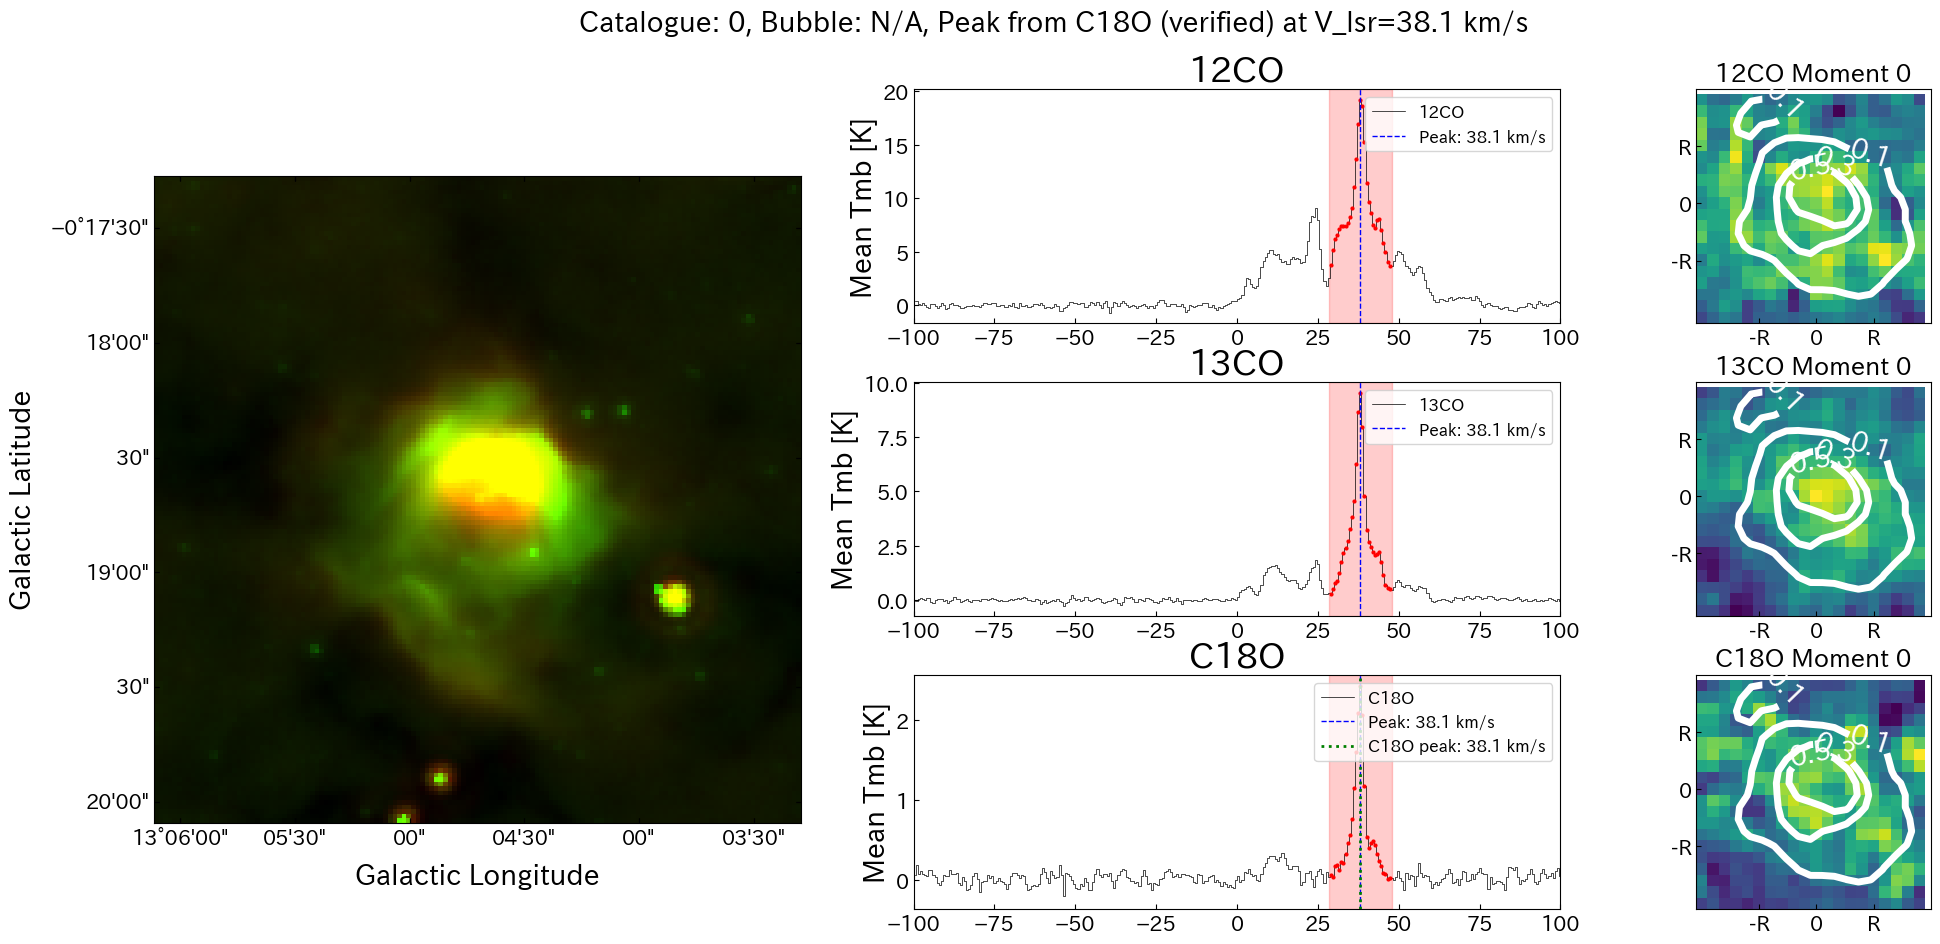

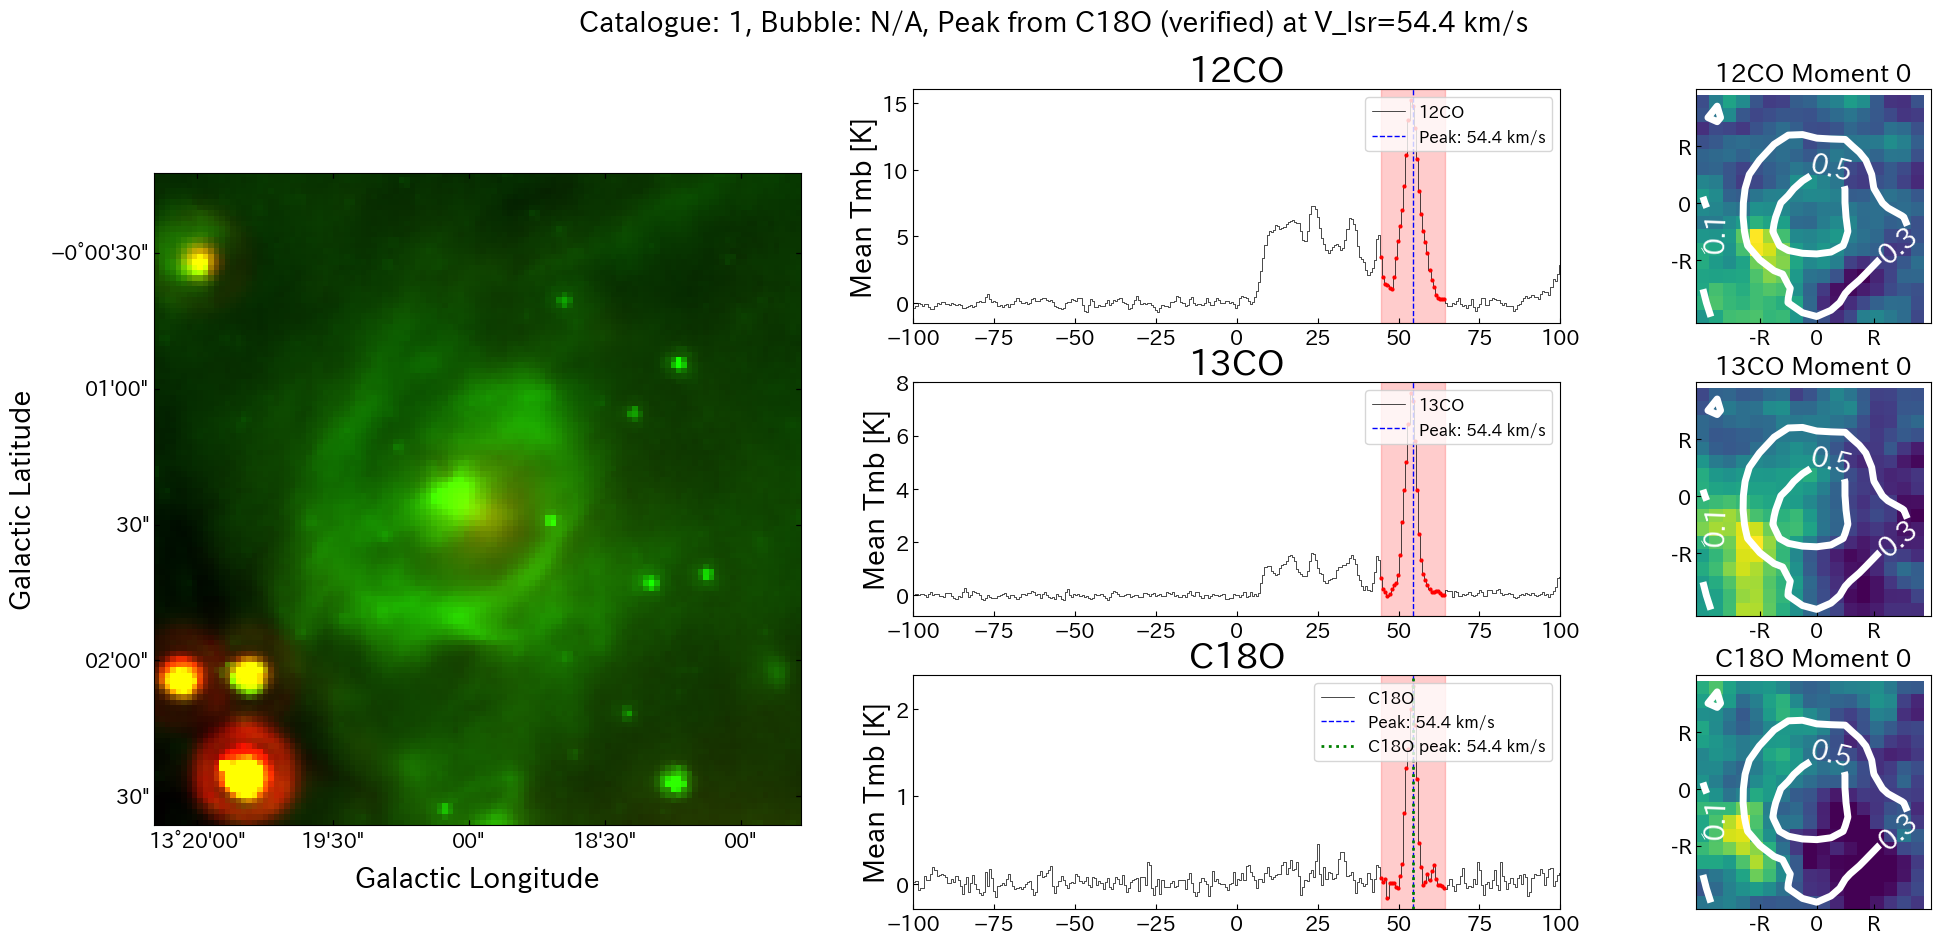

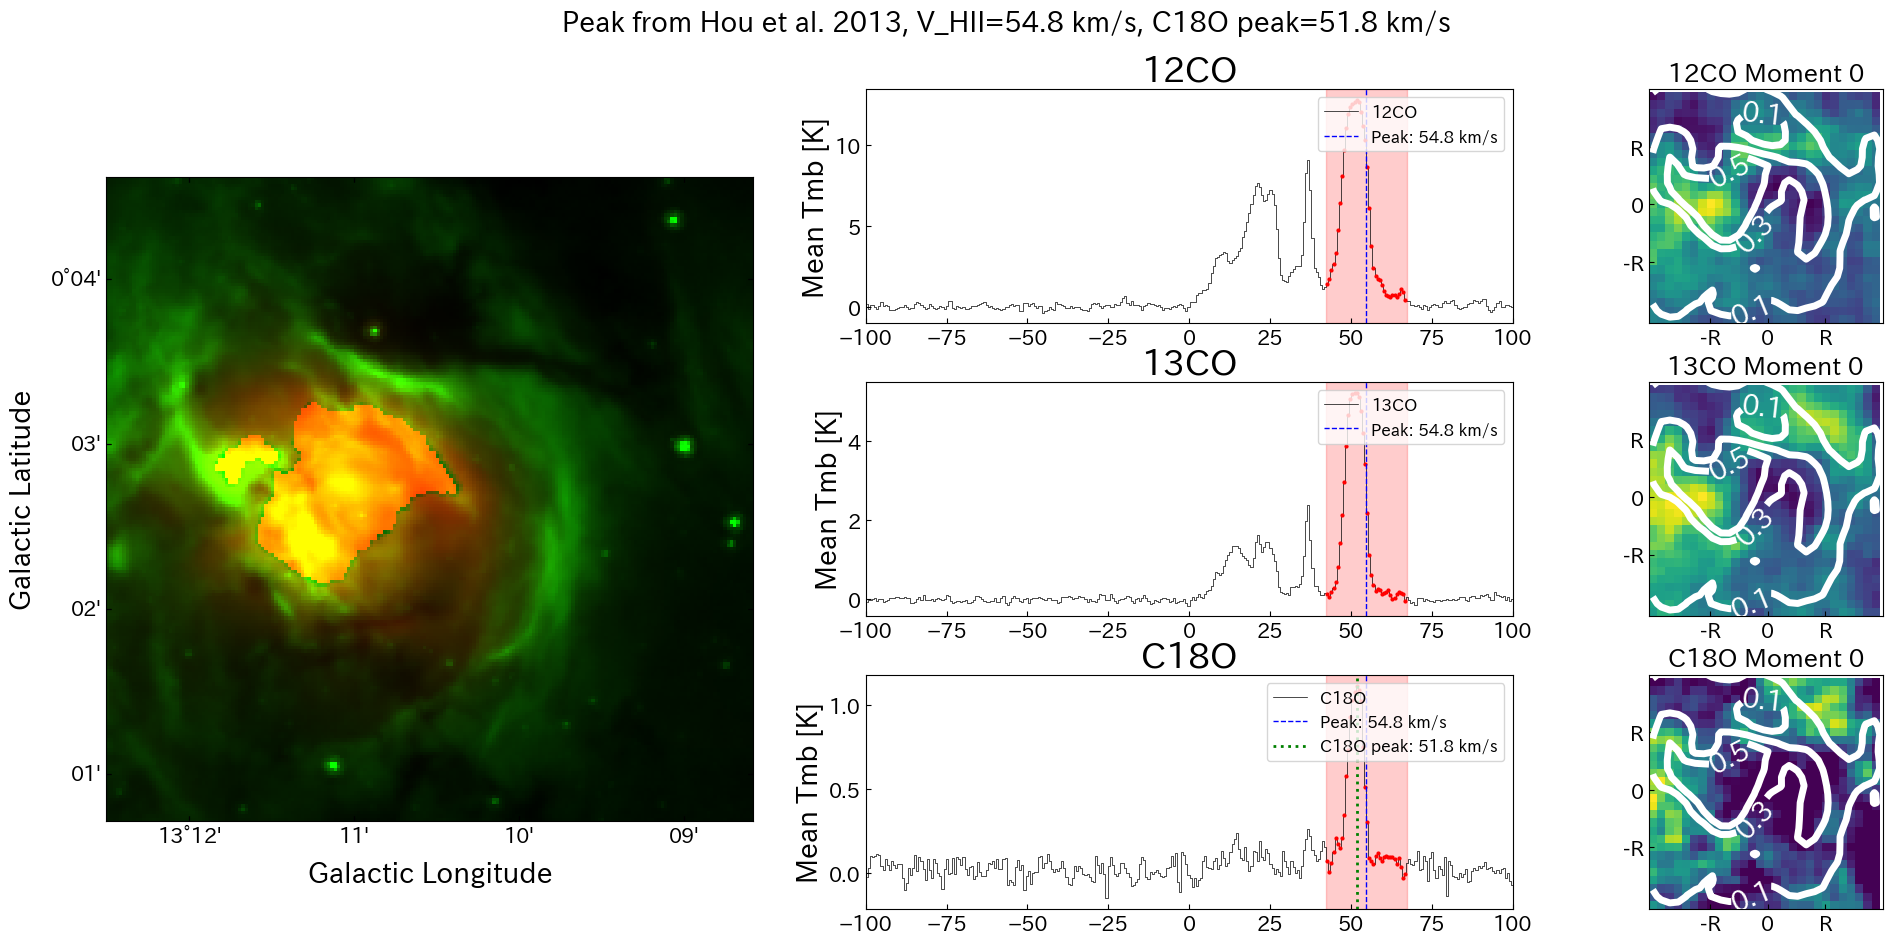

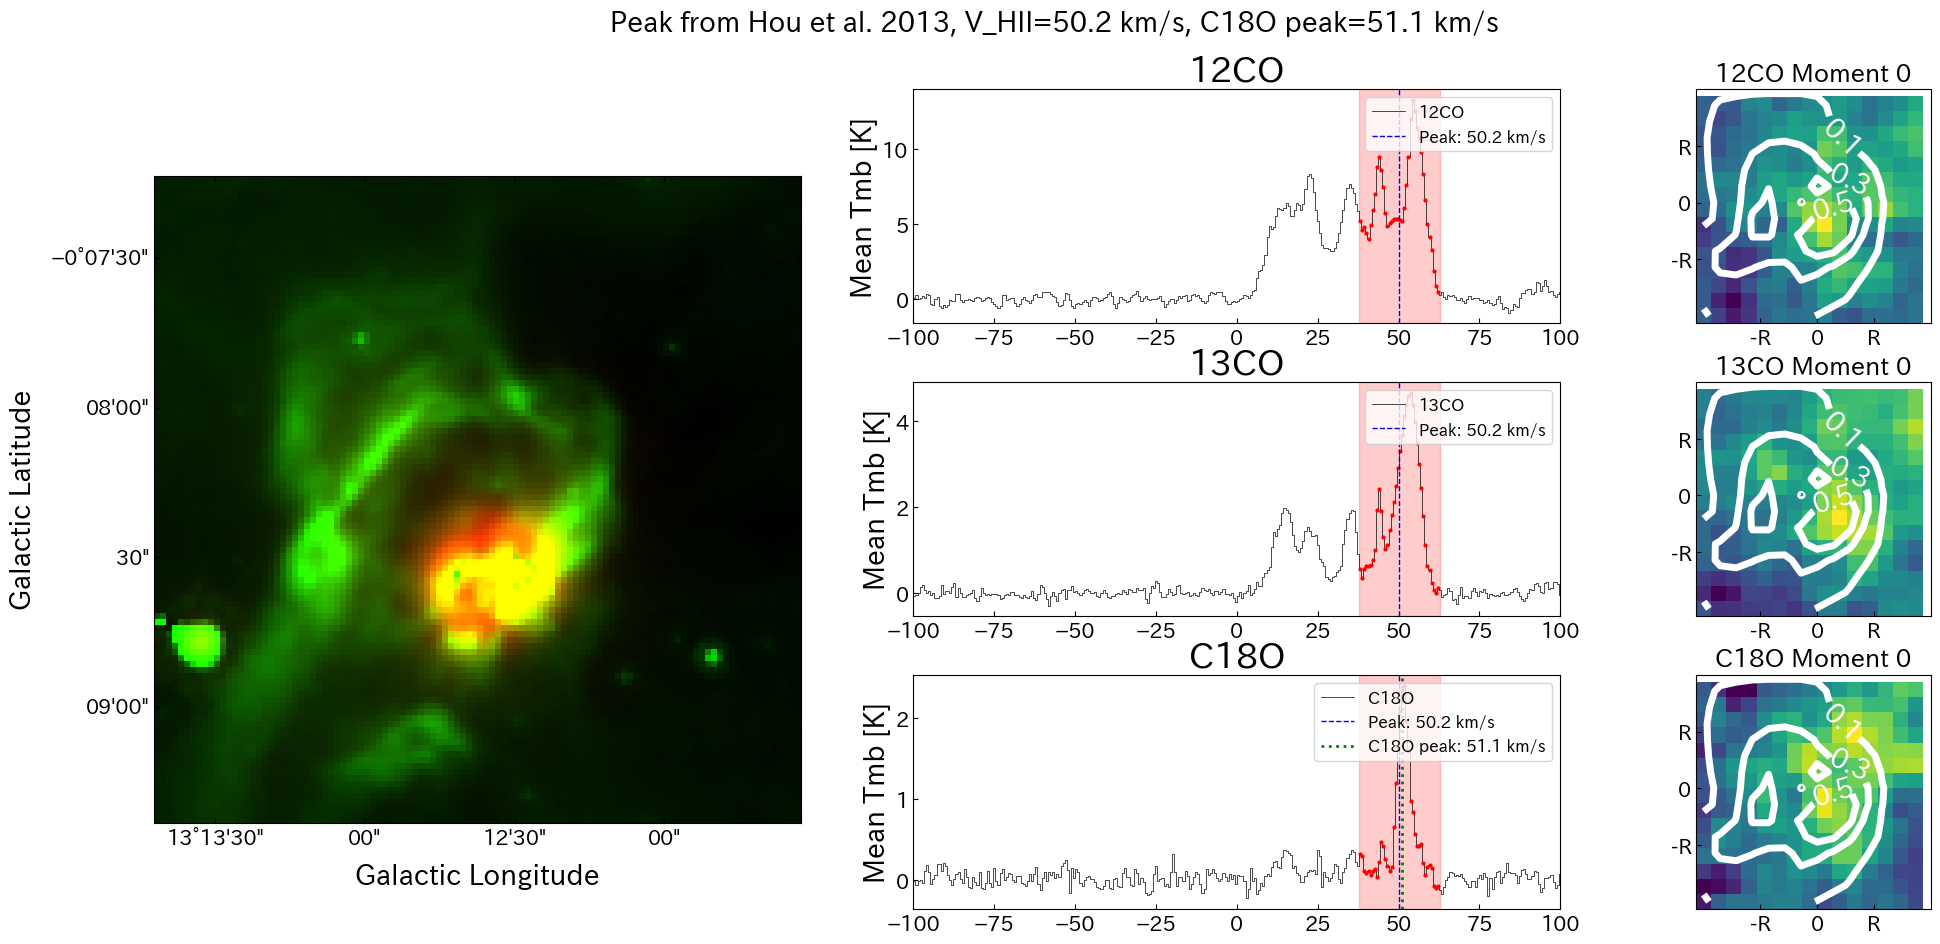

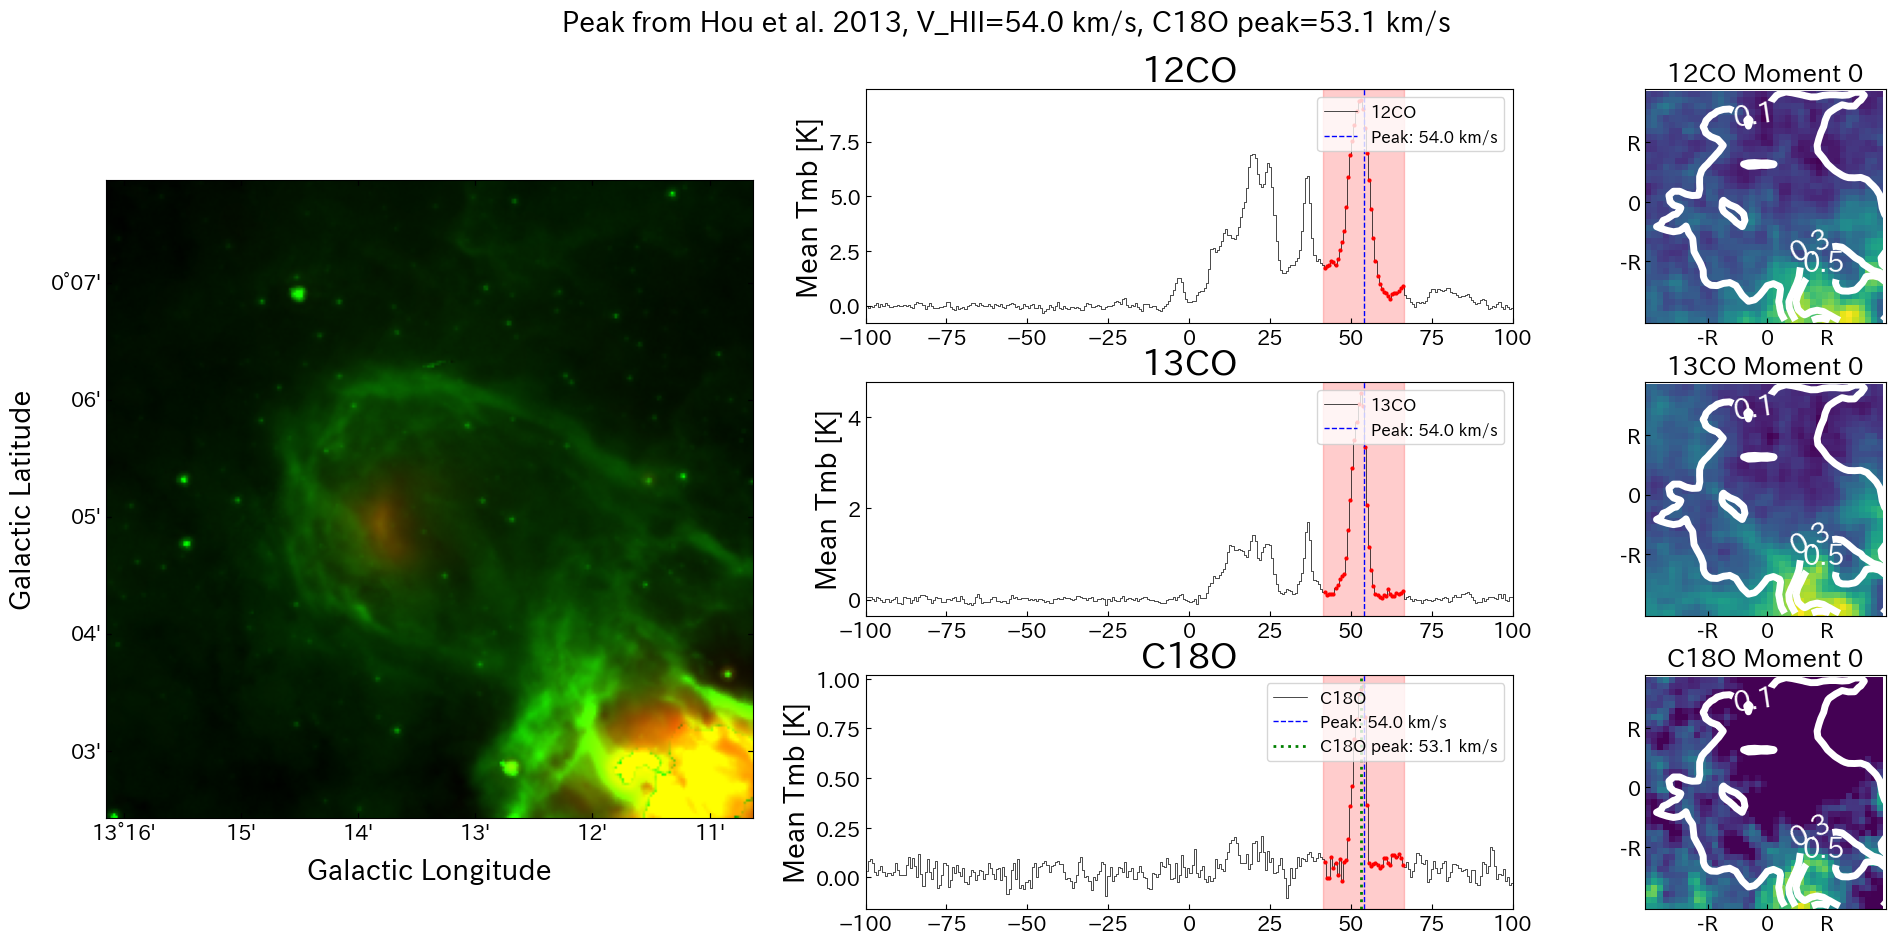

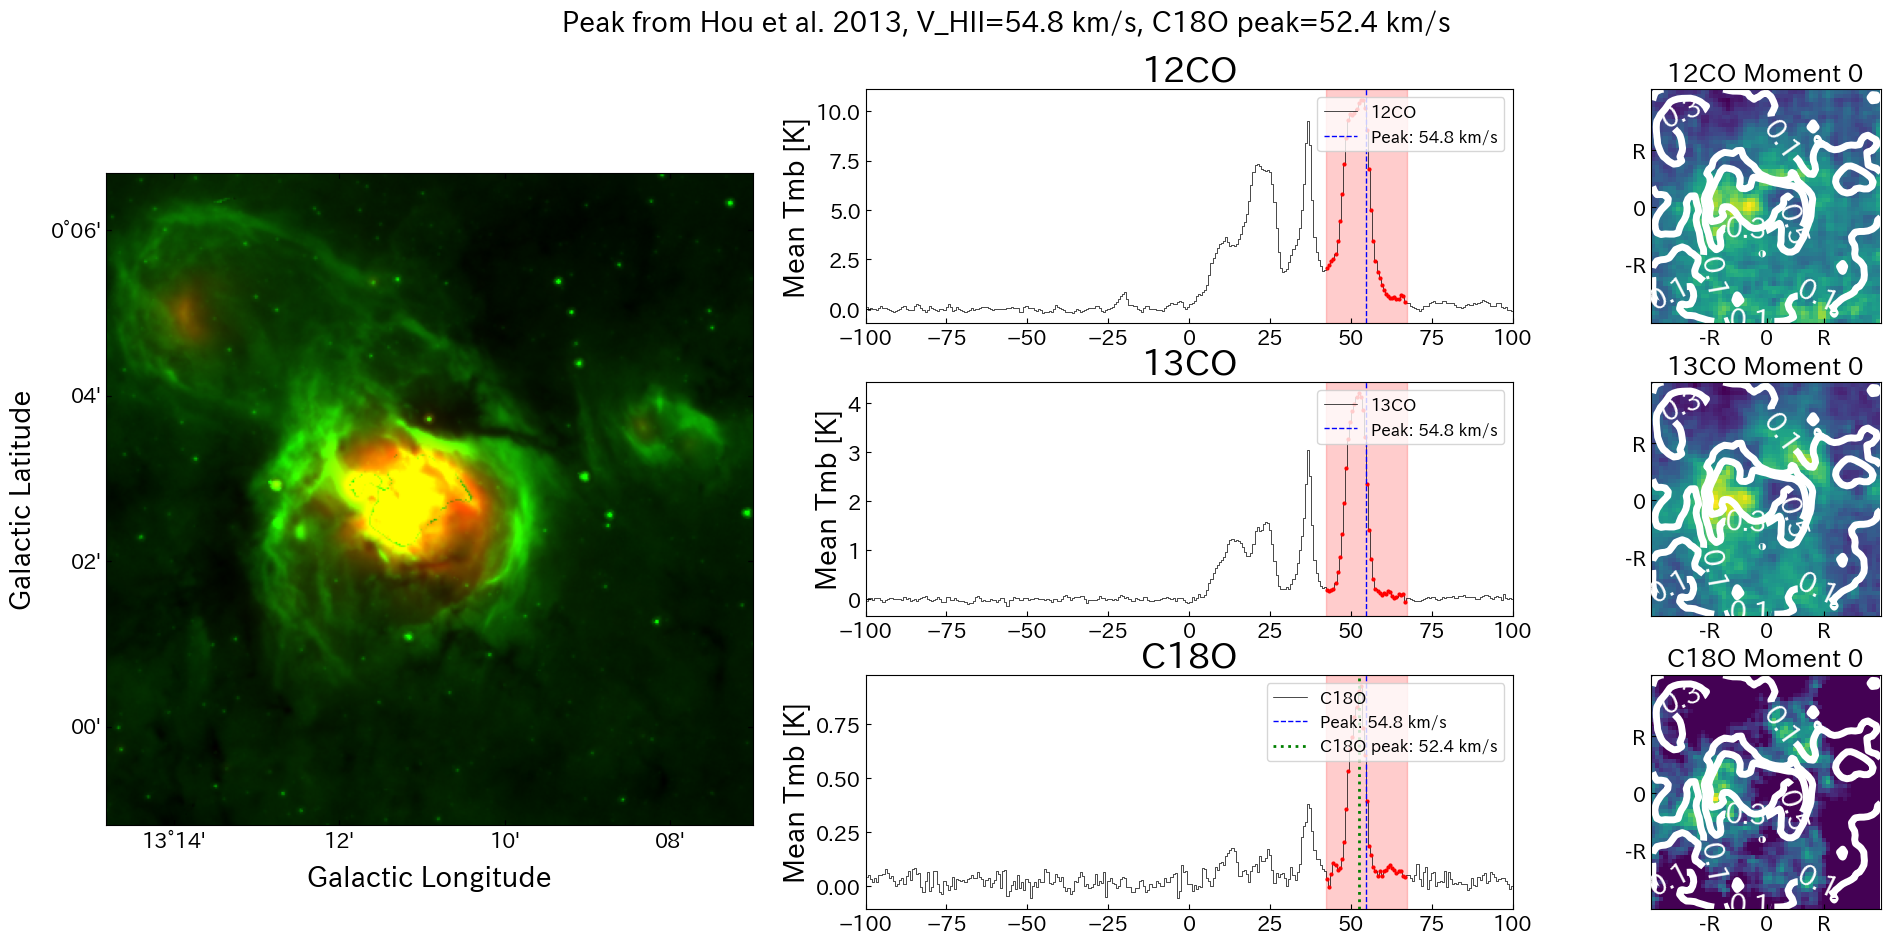

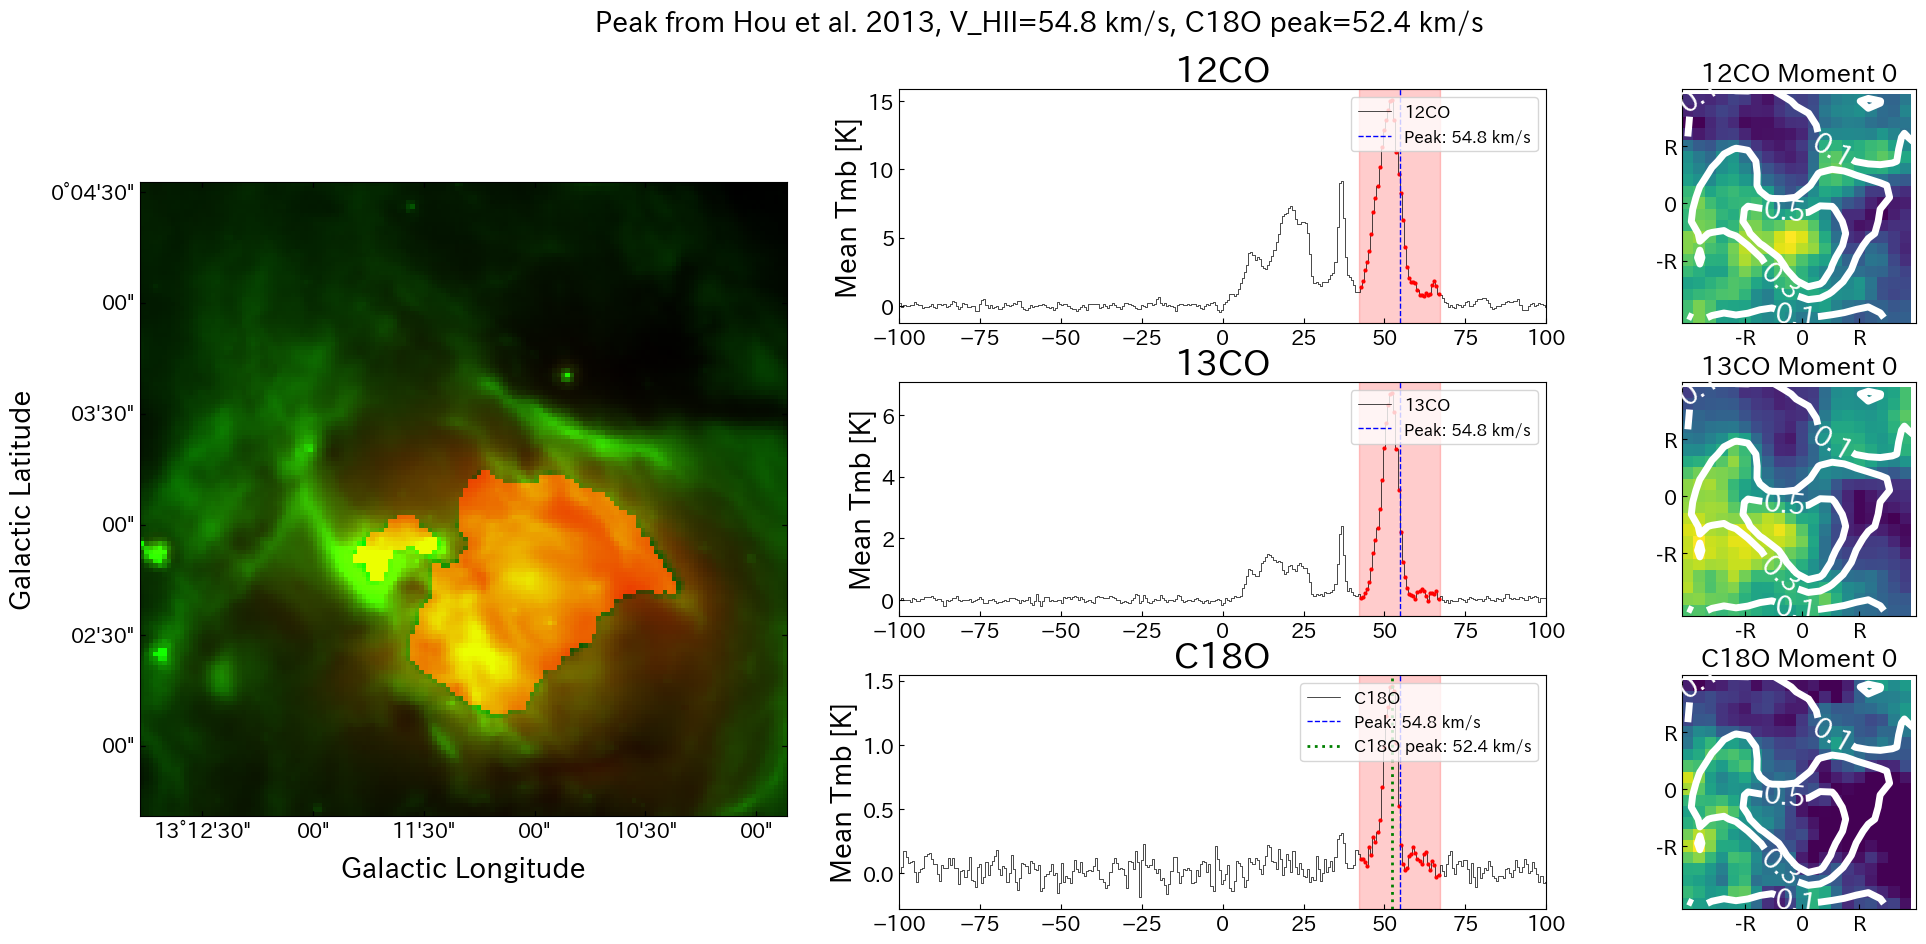

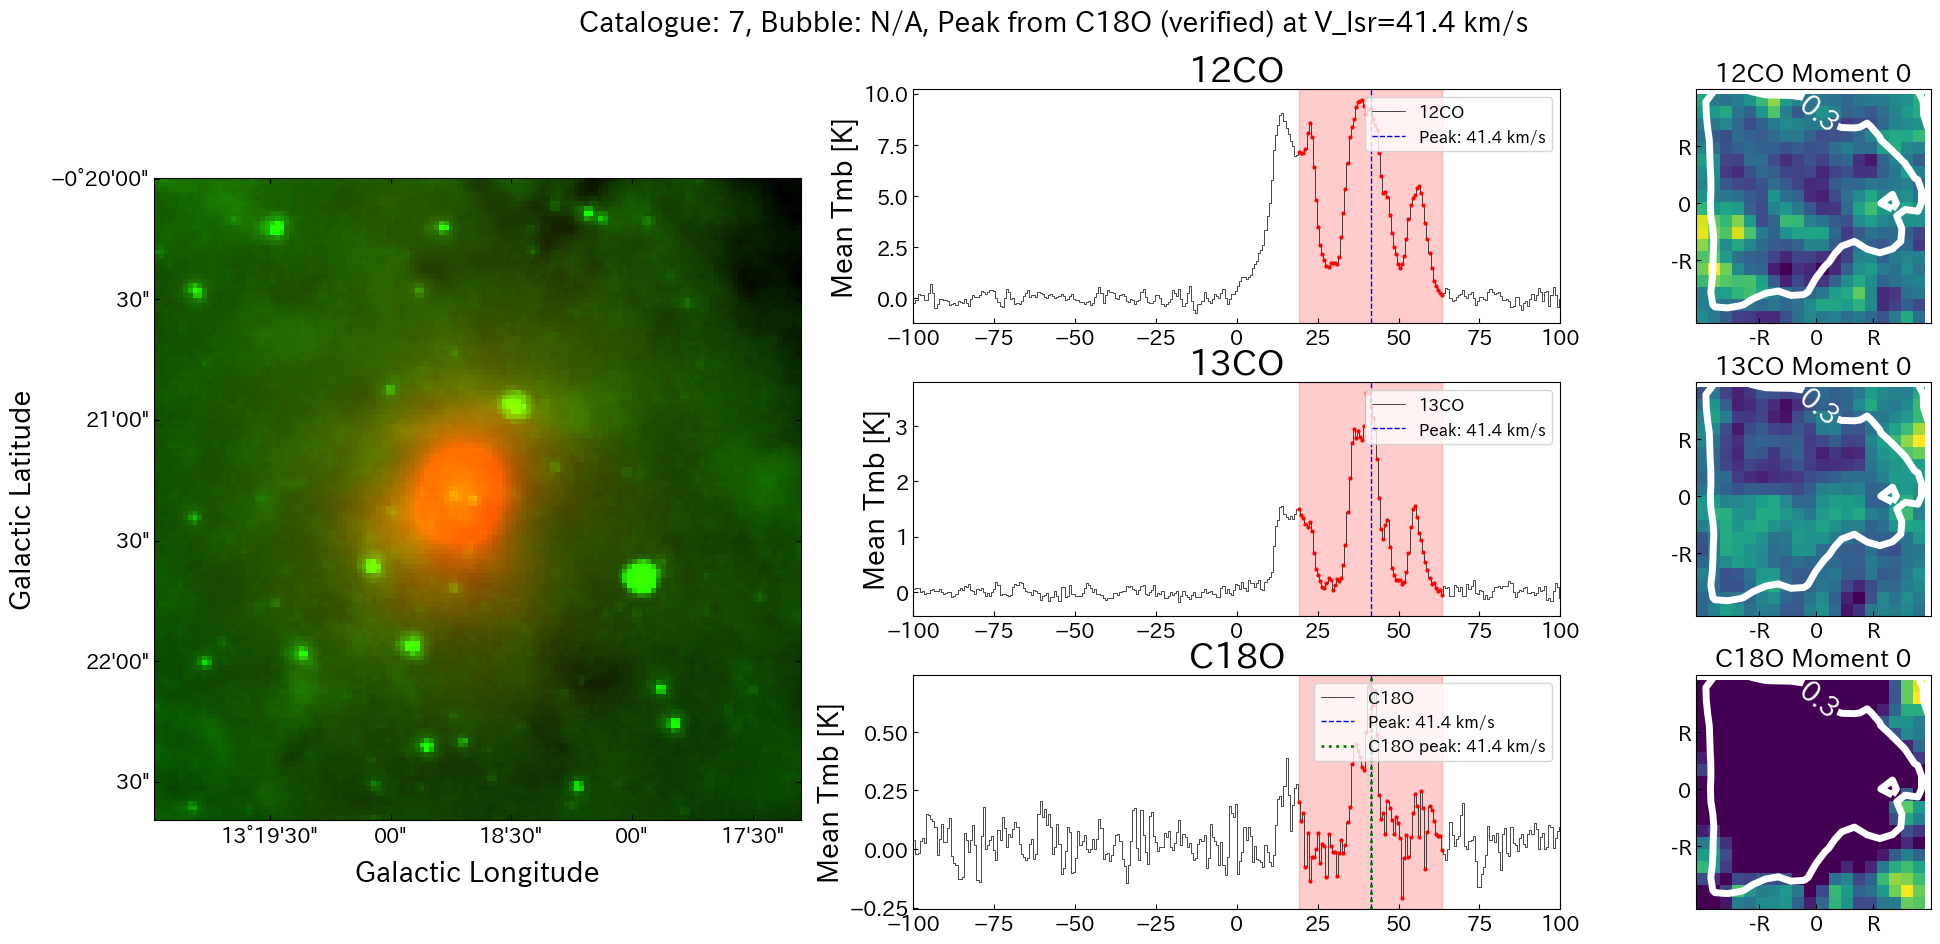

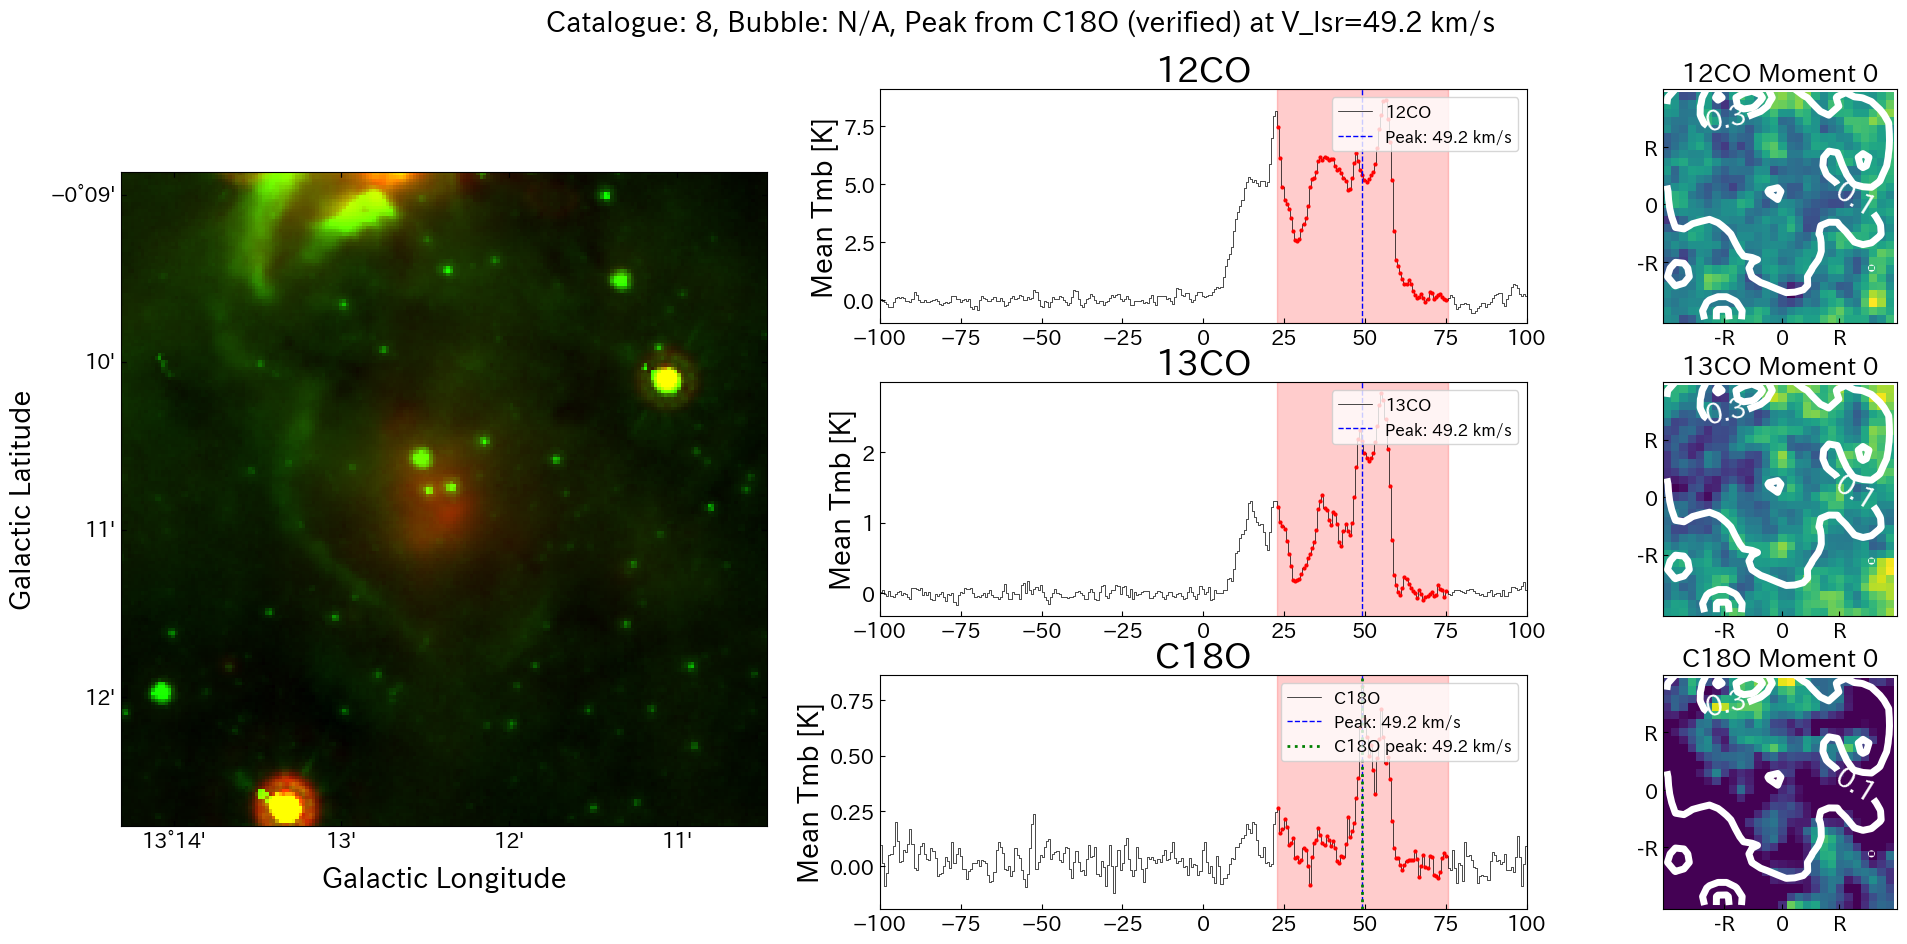

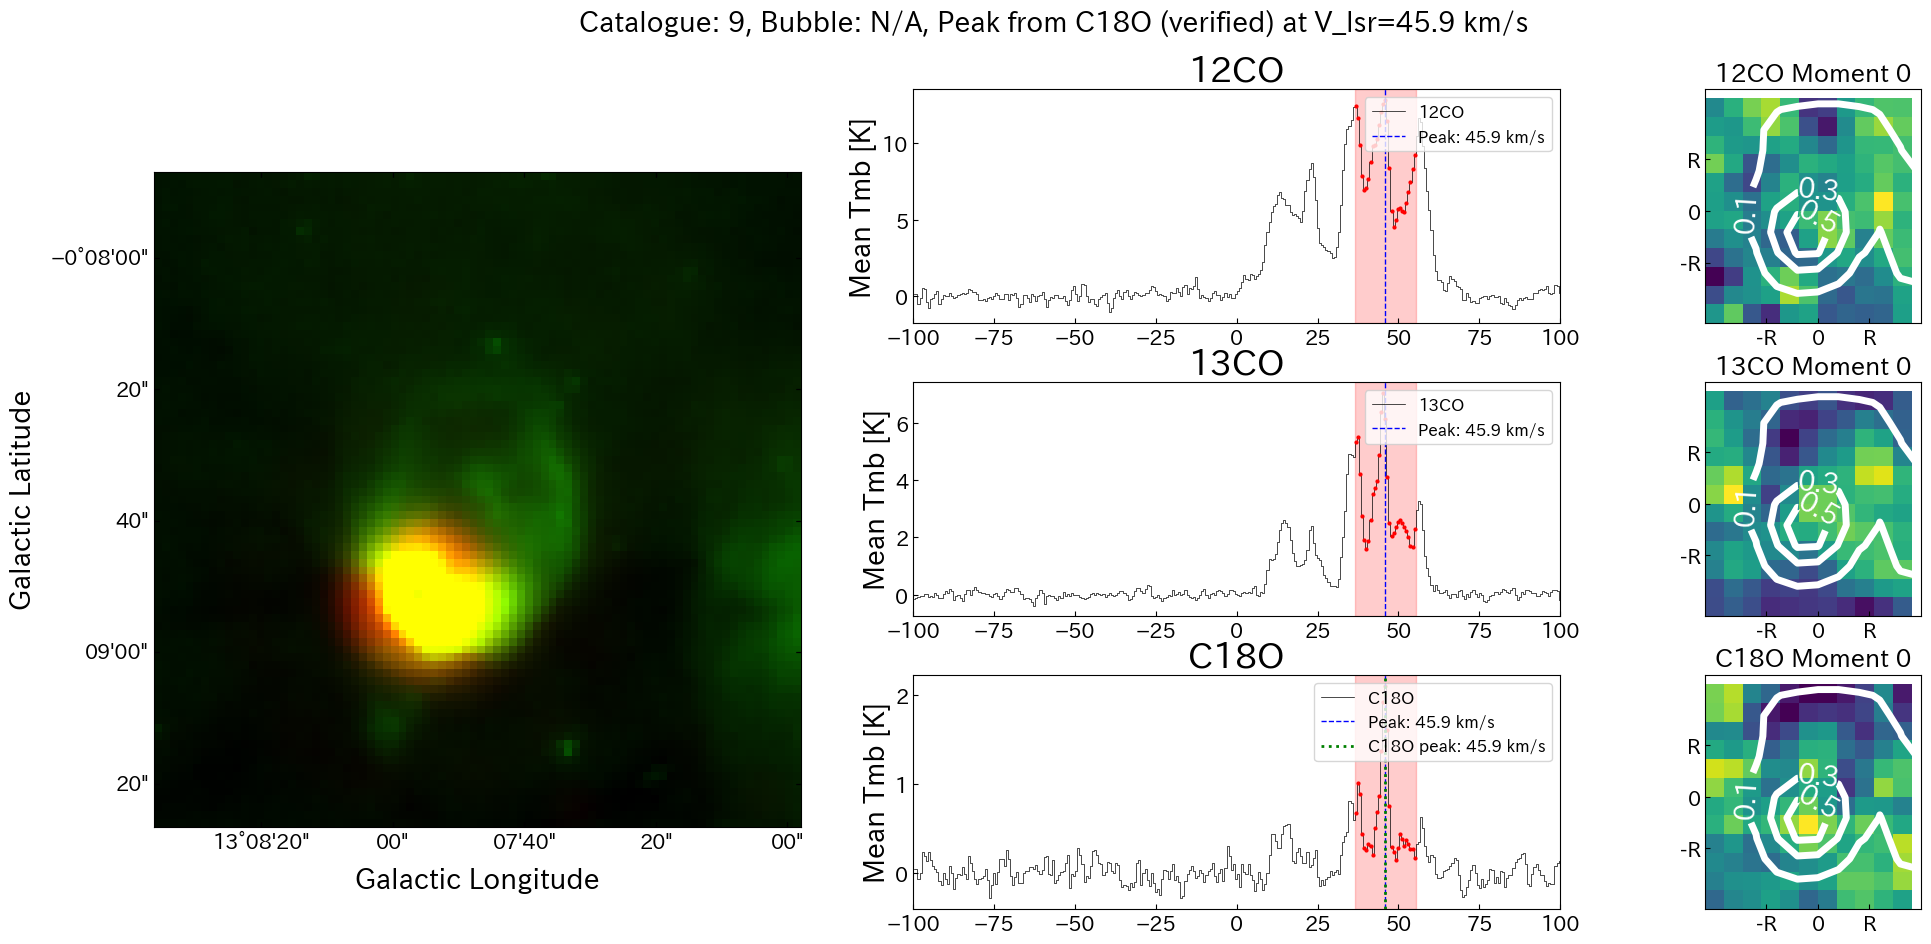

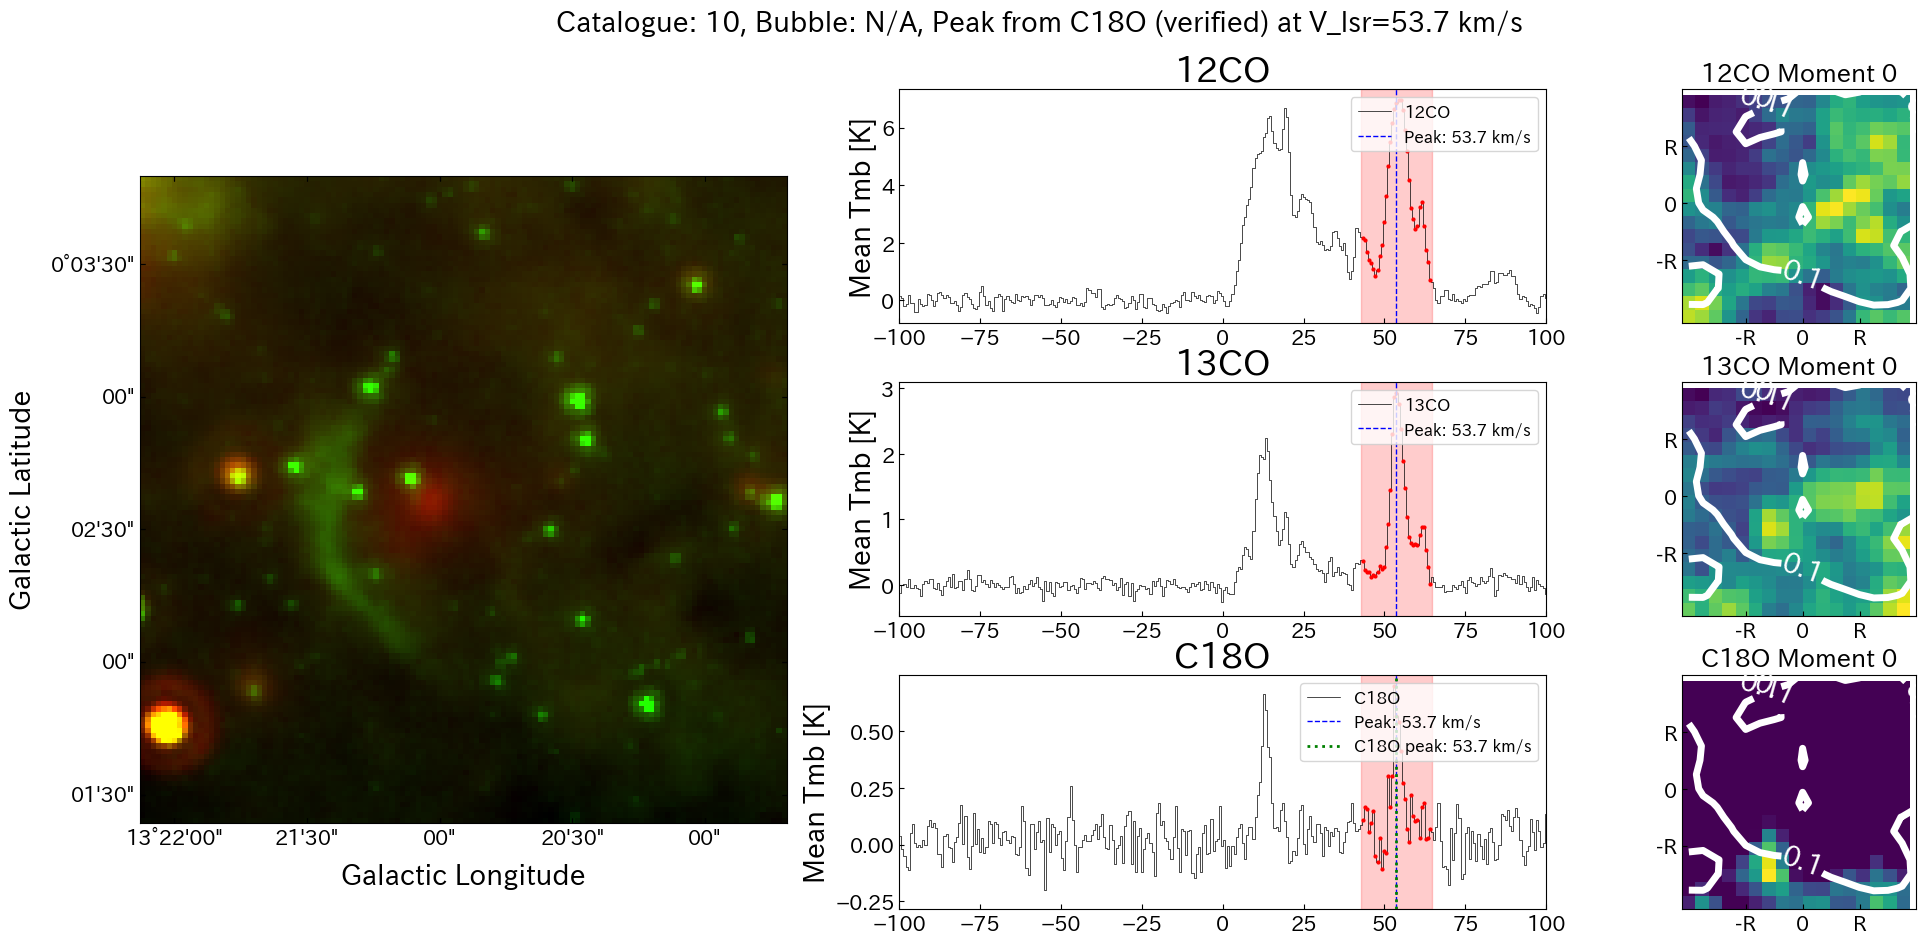

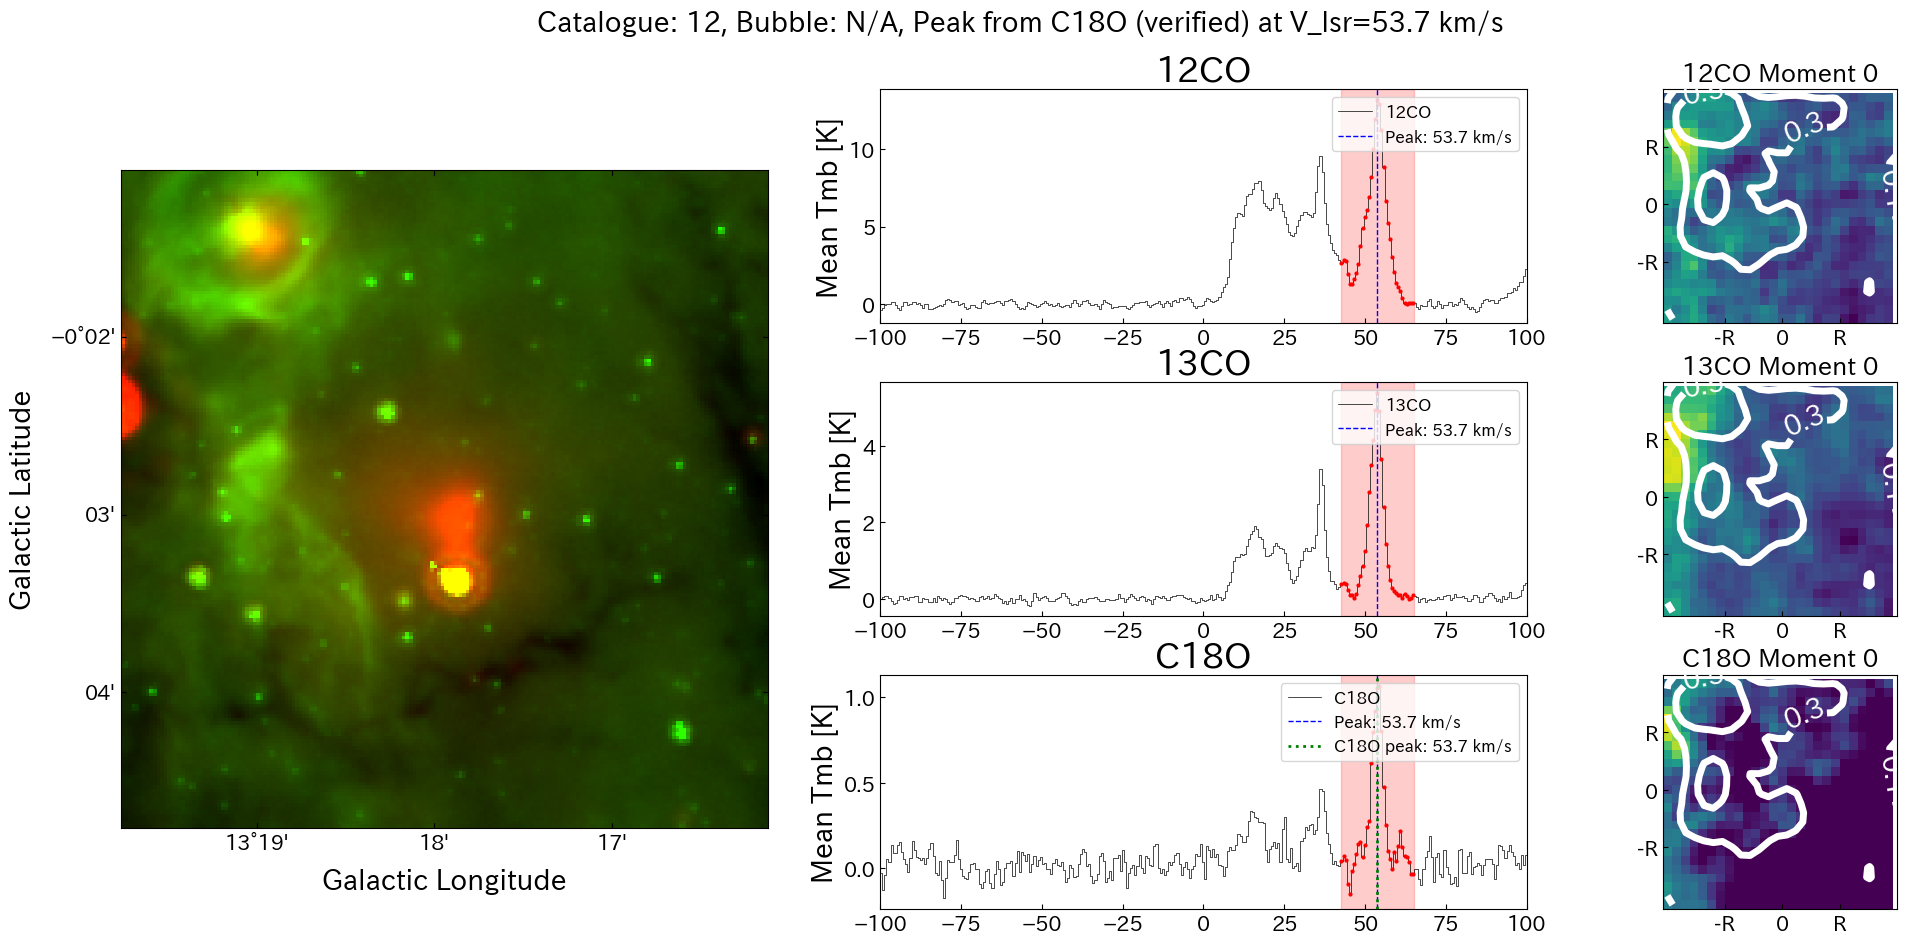

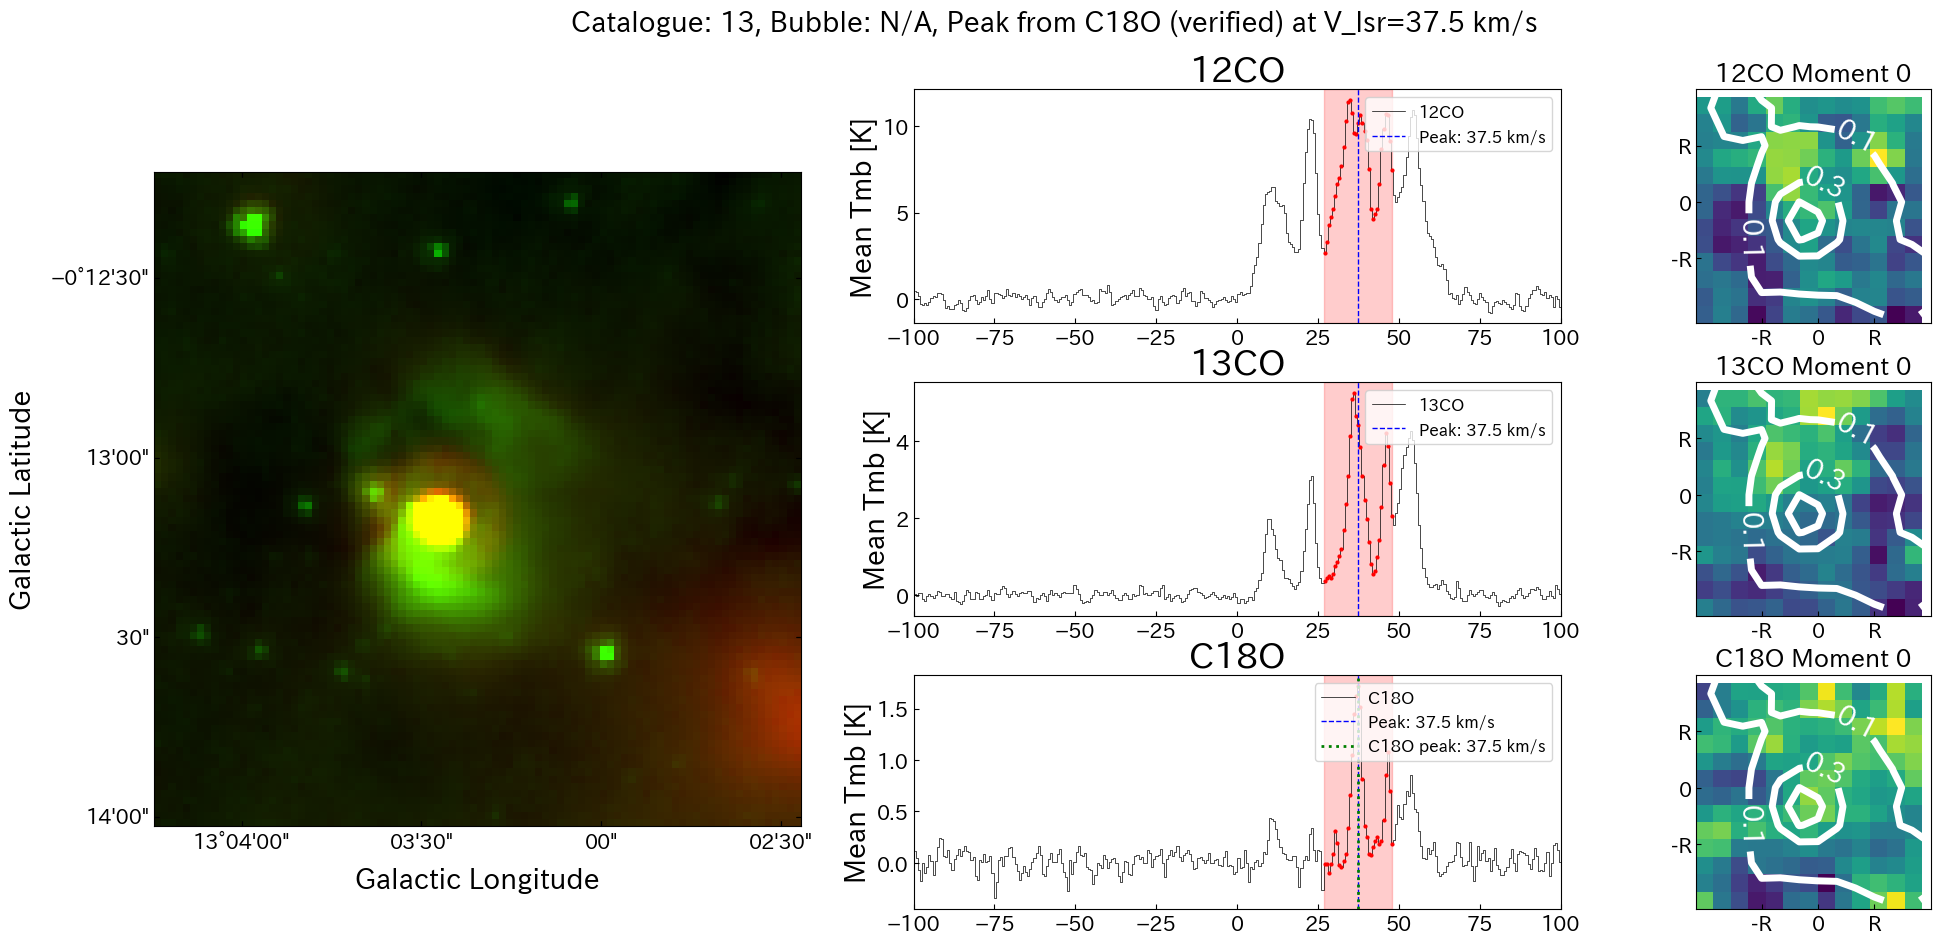

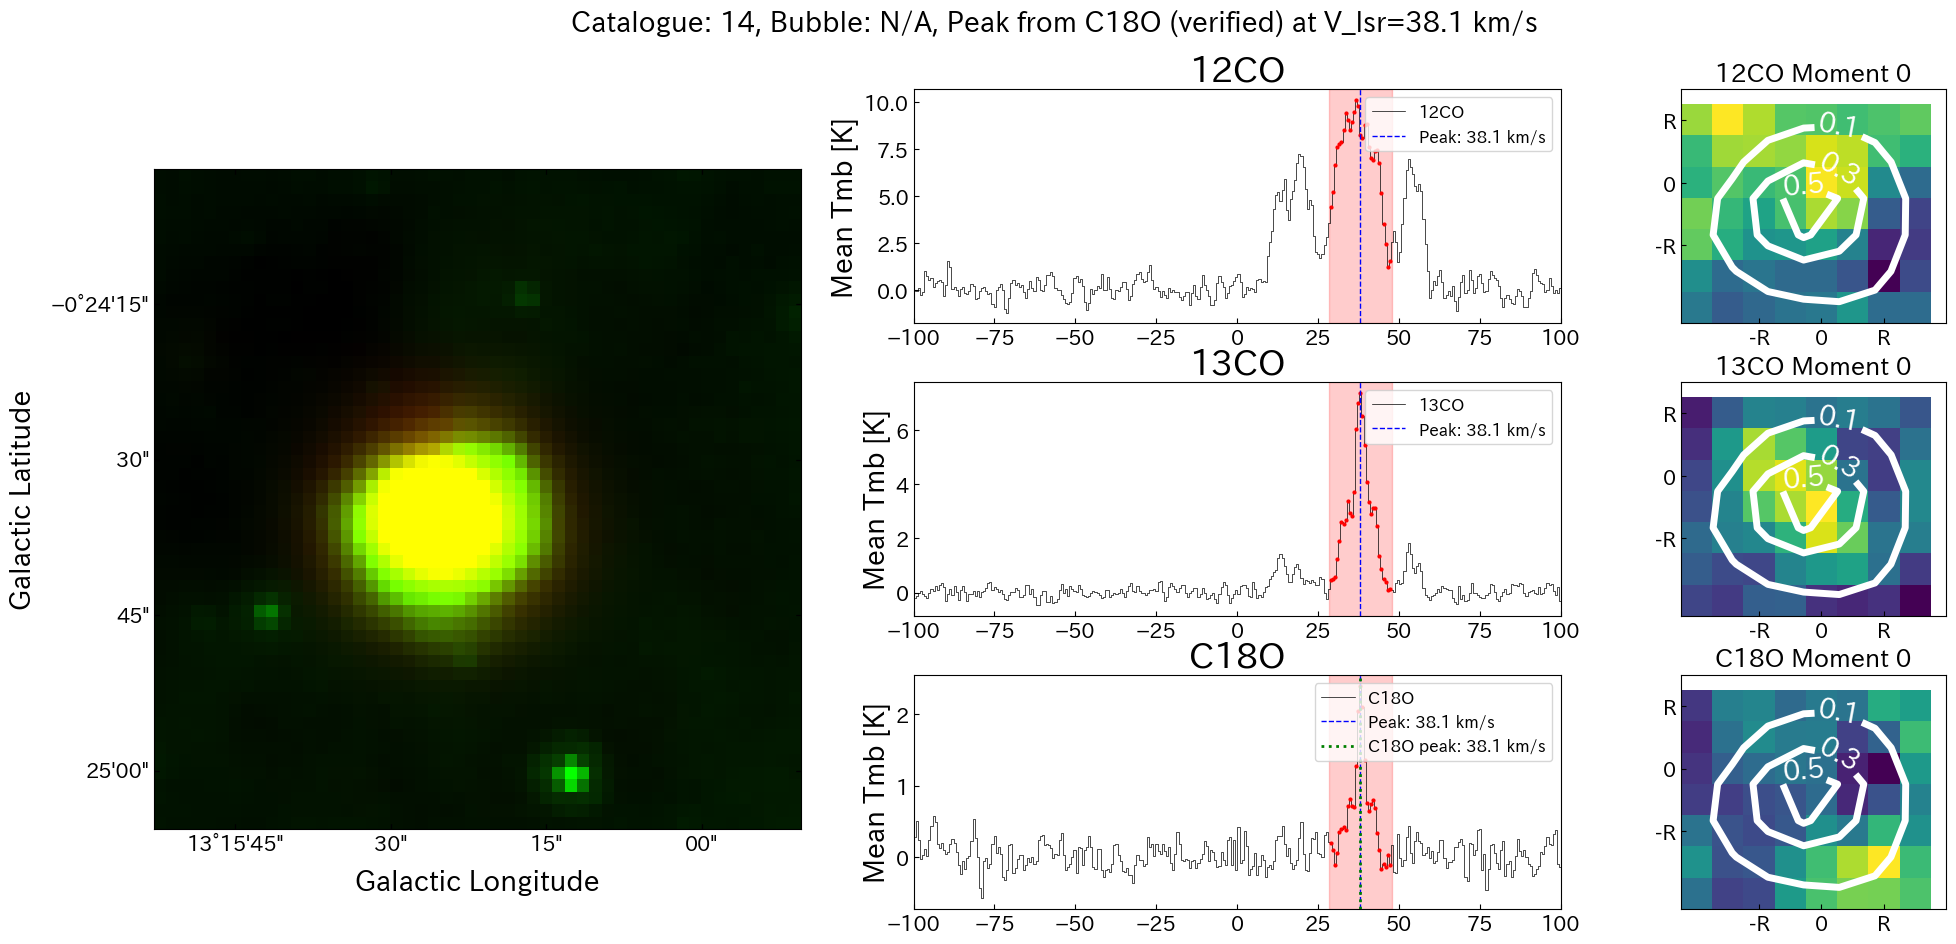

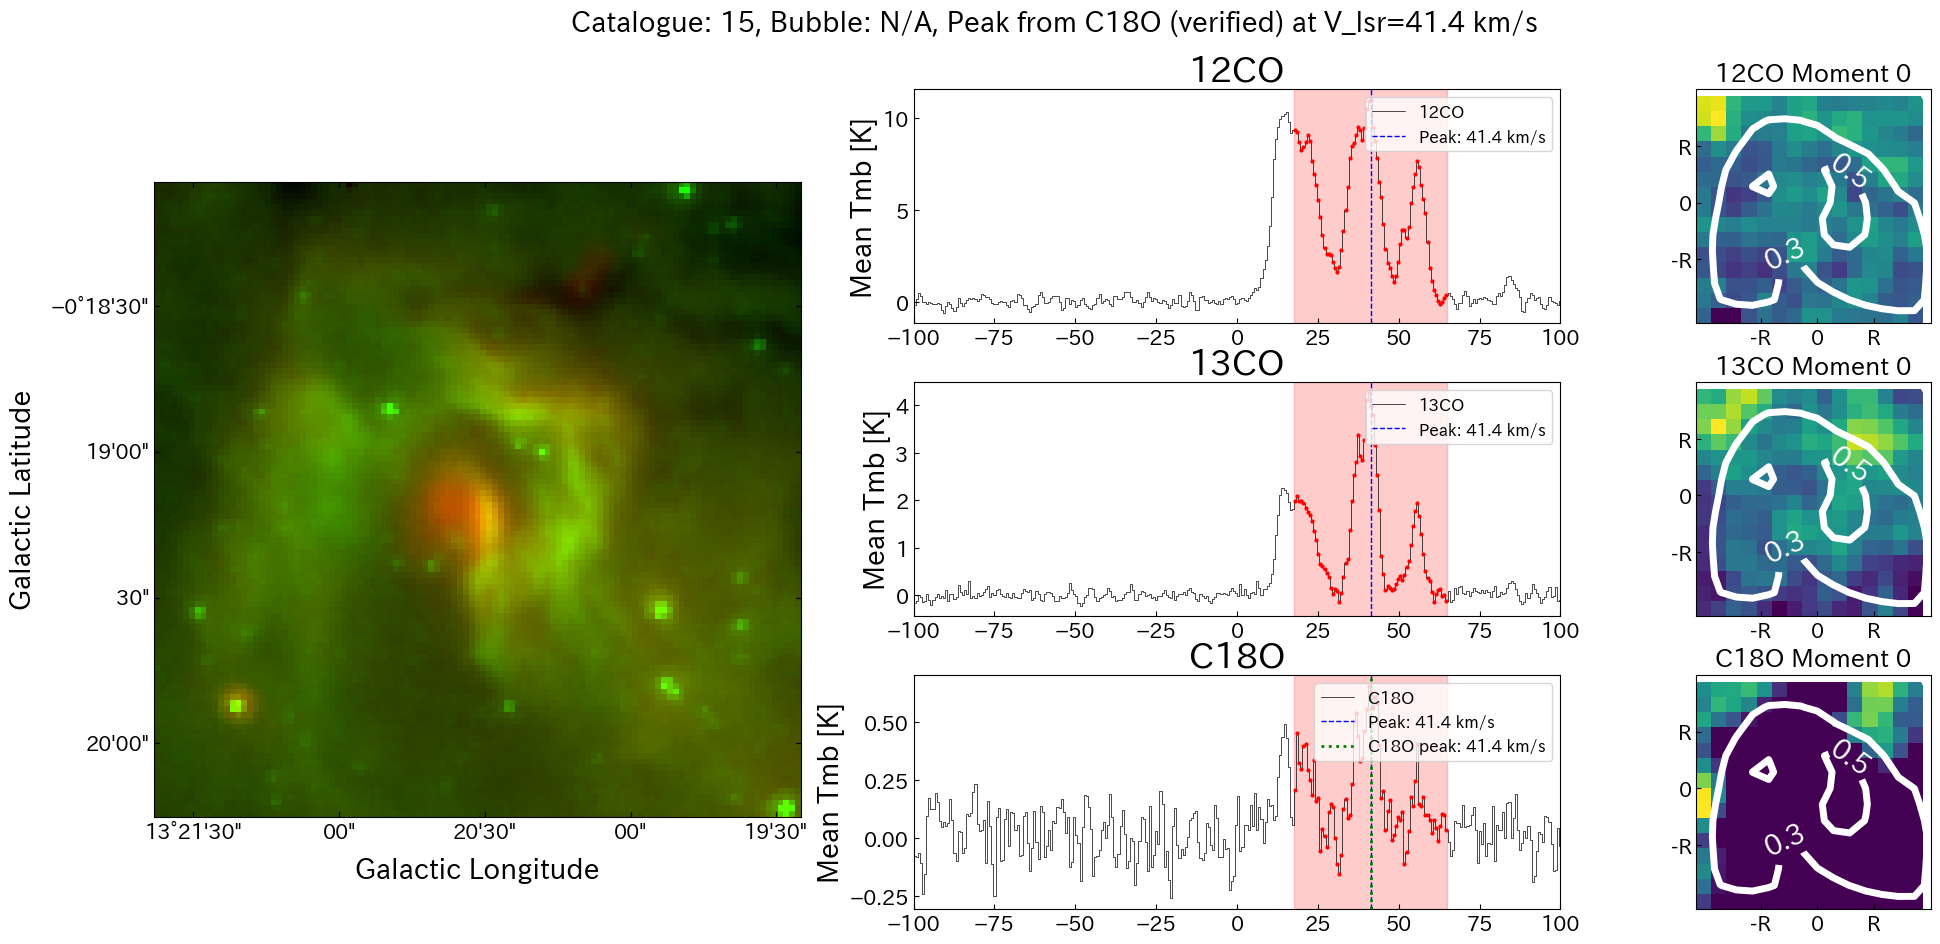

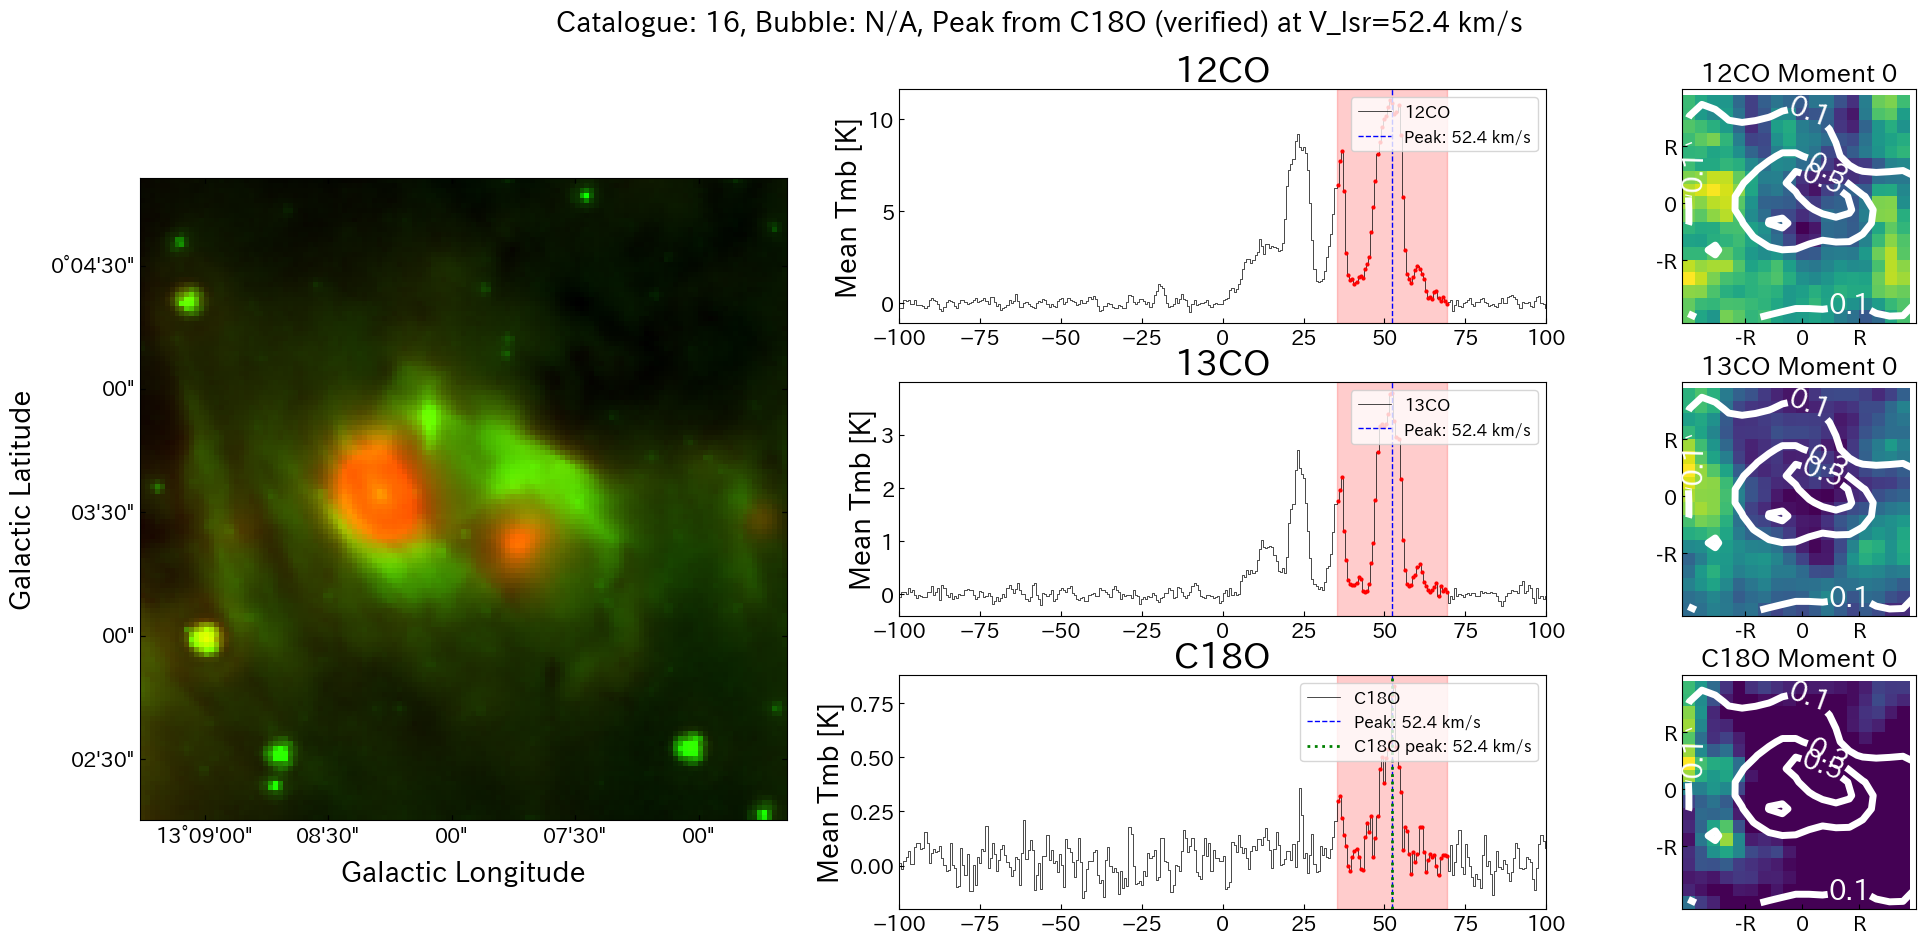

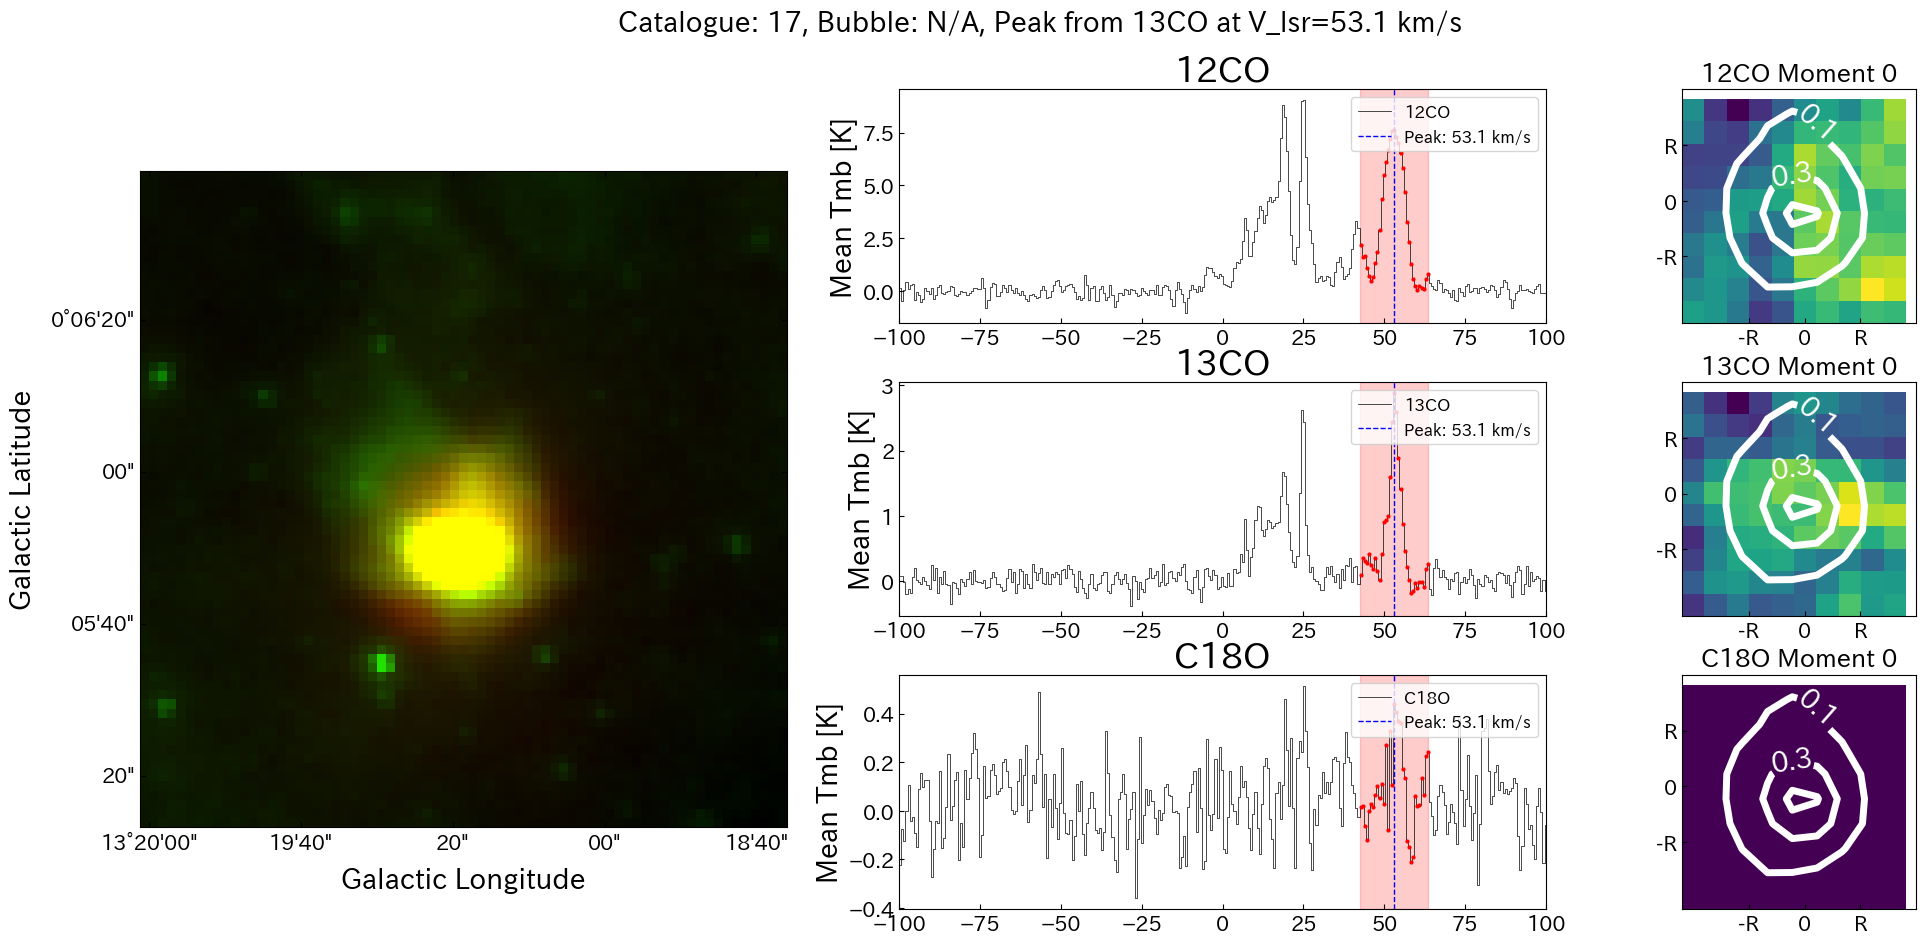

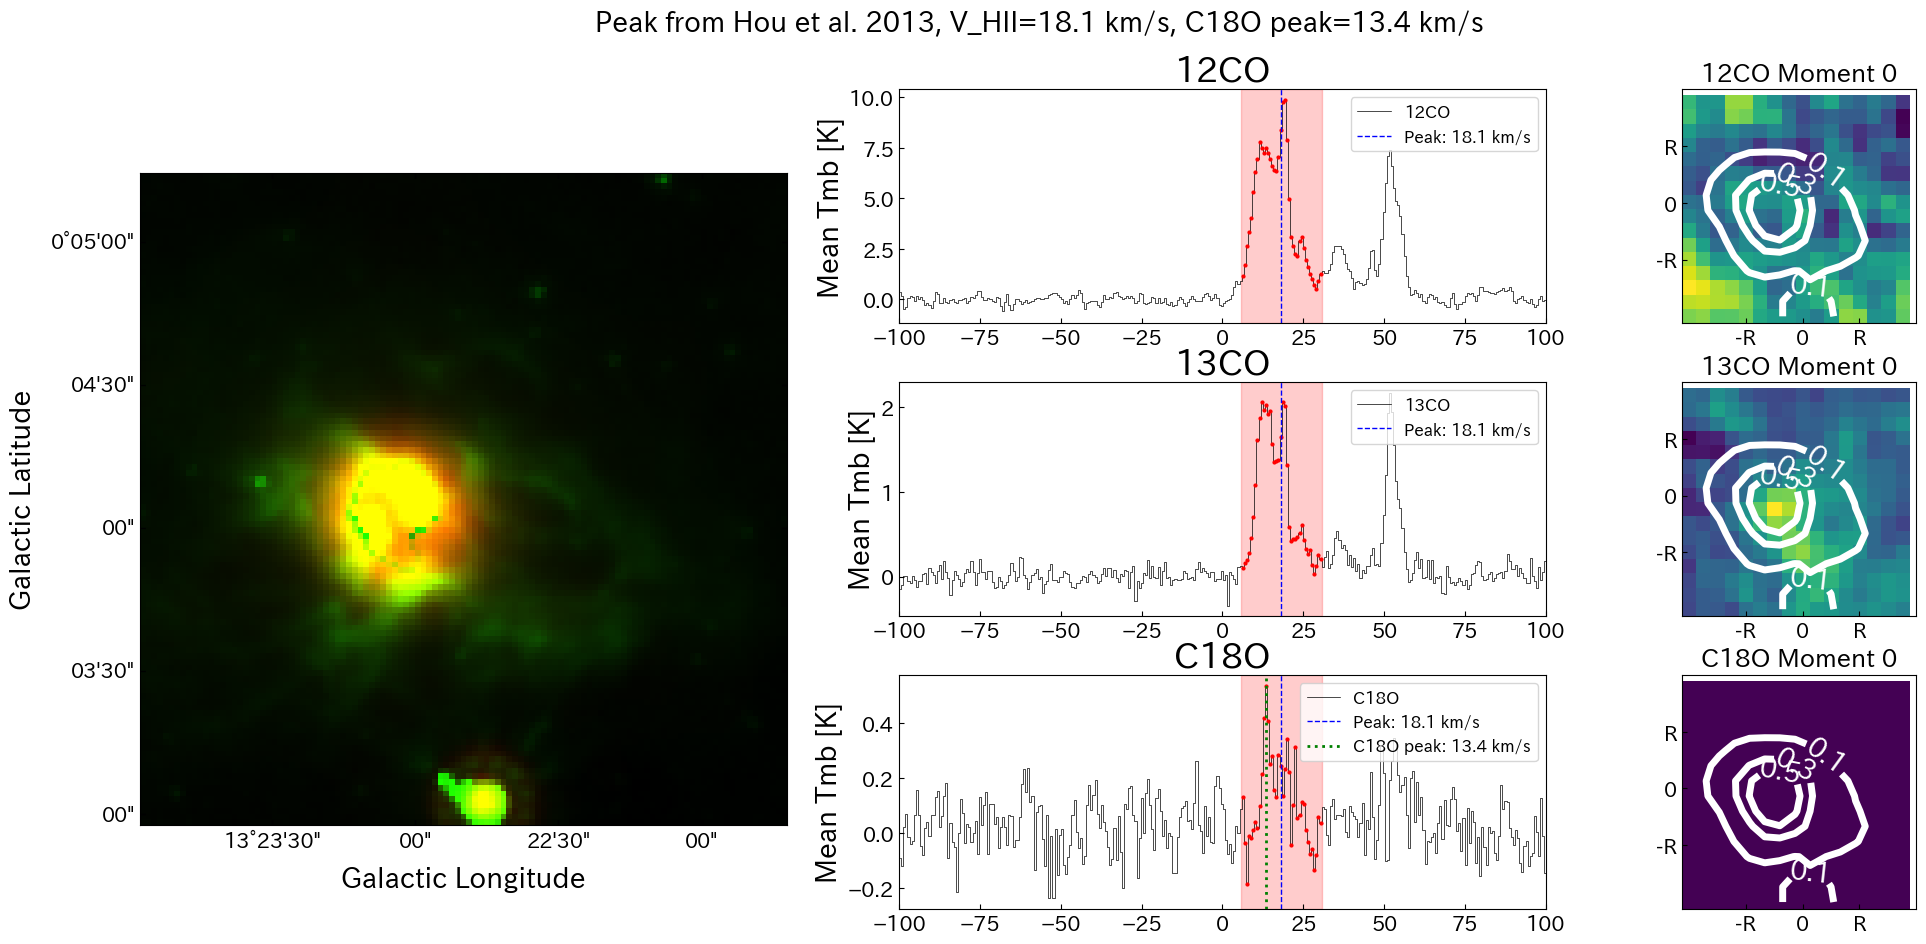

In [46]:
for i, each_catalogue in all_bubble_catalogue_selected.iterrows():
    velocity_stats['total_bubble'] += 1

    # 各バブルの情報を初期化
    bubble_info = {
        'region': region_name,
        'catalogue_index': i,
        'ra_center': each_catalogue['ra_center'],
        'dec_center': each_catalogue['dec_center'],
        'velocity_source': None,
        'v_peak': None,
        'fwhm_vel': None,
        'has_c18o_peak': False,
        'status': None
    }

    # Spitzerデータのロード（キャッシュを利用）
    current_spitzer_path = os.path.join("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/spitzer_data", each_catalogue['fits_path']+'/',)
    if current_spitzer_path != spitzer_path_cached:
        spitzer_rfits, spitzer_gfits, spitzer_data, w_spitzer = load_spitzer_fits(current_spitzer_path)
        spitzer_path_cached = current_spitzer_path

    # スペクトルデータを抽出
    cut_data_12CO = extract_spectral(w_co, fugin_cube_fits_12CO, each_catalogue)
    cut_data_13CO = extract_spectral(w_co, fugin_cube_fits_13CO, each_catalogue)
    cut_data_C18O = extract_spectral(w_co, fugin_cube_fits_C18O, each_catalogue)

    zeroing_cut_data_12CO = extract_spectral(w_co, Zeroing_fugin_cube_fits_12CO, each_catalogue)
    zeroing_cut_data_13CO = extract_spectral(w_co, Zeroing_fugin_cube_fits_13CO, each_catalogue)
    zeroing_cut_data_C18O = extract_spectral(w_co, Zeroing_fugin_cube_fits_C18O, each_catalogue)

    # 平均スペクトルを計算
    mean_data_12CO = np.nanmean(cut_data_12CO, axis=(1, 2))
    mean_data_13CO = np.nanmean(cut_data_13CO, axis=(1, 2))
    mean_data_C18O = np.nanmean(cut_data_C18O, axis=(1, 2))

    # C18Oのピーク検証
    c18o_v_peak, c18o_t_peak, c18o_fwhm_vel, c18o_peak_channel = find_verified_peak(
        c18o_spec=mean_data_C18O,
        co12_spec=mean_data_12CO,
        co13_spec=mean_data_13CO,
        vaxis=vaxis, dv=dv
    )

    bubble_info['has_c18o_peak'] = c18o_v_peak is not None

    # カタログから速度情報を検索
    catalog_v_peak, catalog_fwhm_vel, catalog_info = find_velocity_from_catalog(
        each_catalogue['ra_center'], 
        each_catalogue['dec_center'], 
        bub_velocity_table,
        search_radius=(each_catalogue['dec_max'] - each_catalogue['dec_min'])/2
    )

    if catalog_v_peak is not None:
        used_tracer = f"Catalog (Row {catalog_info['catalog_index']})"
        v_peak = catalog_v_peak
        fwhm_vel = catalog_fwhm_vel
        t_peak = np.nan
        peak_channel = np.argmin(np.abs(vaxis - v_peak))
        
        # C18Oピークとの整合性チェック
        if bubble_info['has_c18o_peak'] and abs(c18o_v_peak - catalog_v_peak) <= 10.0:
            velocity_stats['catalogue_vel_with_c18o'] += 1
        else:
            bubble_info['has_c18o_peak'] = False 
        
        velocity_stats['catalogue_vel_bubble'] += 1
        bubble_info.update({'velocity_source': 'Catalog', 'v_peak': v_peak, 'fwhm_vel': fwhm_vel, 'status': 'Success'})
        
    elif c18o_v_peak is not None:
        used_tracer = "C18O (verified)"
        v_peak, t_peak, fwhm_vel, peak_channel = c18o_v_peak, c18o_t_peak, c18o_fwhm_vel, c18o_peak_channel
        velocity_stats['c18o_vel_bubble'] += 1
        bubble_info.update({'velocity_source': 'C18O', 'v_peak': v_peak, 'fwhm_vel': fwhm_vel, 'status': 'Success'})
        
    else:
        used_tracer = "13CO"
        v_peak, t_peak, fwhm_vel, peak_channel = _detect_and_characterize_peak(
            mean_data_13CO, vaxis, dv, height_factor=5.0, prominence_factor=3.0
        )
        if v_peak is not None:
            velocity_stats['co13_vel_bubble'] += 1
            bubble_info.update({'velocity_source': '13CO', 'v_peak': v_peak, 'fwhm_vel': fwhm_vel, 'status': 'Success'})
        else:
            velocity_stats['no_vel_bubble'] += 1
            bubble_info.update({'velocity_source': 'None', 'status': 'No velocity detected'})
            bubble_details.append(bubble_info)
            continue

    # 速度範囲の設定
    range_start_vel = v_peak - fwhm_vel * 2.5
    range_end_vel = v_peak + fwhm_vel * 2.5
    range_indices = np.where((vaxis >= range_start_vel) & (vaxis <= range_end_vel))[0]
    # print(range_indices)

    # Momentマップ作成
    datadict_12CO = make_momont012_map(fugin_cube_fits_12CO, w_co, zeroing_cut_data_12CO[range_indices], vaxis[range_indices], v_center=v_peak)
    datadict_13CO = make_momont012_map(fugin_cube_fits_13CO, astropy.wcs.WCS(fugin_cube_fits_13CO.header), zeroing_cut_data_13CO[range_indices], vaxis[range_indices], v_center=v_peak)
    datadict_C18O = make_momont012_map(fugin_cube_fits_C18O, astropy.wcs.WCS(fugin_cube_fits_C18O.header), zeroing_cut_data_C18O[range_indices], vaxis[range_indices], v_center=v_peak)

    # Spitzer画像の準備
    new_hdu_list_r, new_hdu_list_g = make_spitzer_fits(spitzer_rfits, spitzer_gfits, w_spitzer, spitzer_data, each_catalogue)
    if new_hdu_list_r == 0:
        velocity_stats['spitzer_error_bubble'] += 1
        bubble_info['status'] = 'Spitzer error'
        bubble_details.append(bubble_info)
        continue

    cut_spitzer = np.concatenate([
        new_hdu_list_r[0].data[:,:,None],
        new_hdu_list_g[0].data[:,:,None],
        np.zeros(new_hdu_list_r[0].data.shape)[:,:,None]
    ], axis=2)

    # --- プロット処理 ---
    fig = plt.figure(figsize=(20, 10))

    # 安全な文字列フォーマット (None対策)
    v_peak_str = f"{v_peak:.1f}" if v_peak is not None else "N/A"
    c18o_v_peak_str = f"{c18o_v_peak:.1f}" if c18o_v_peak is not None else "N/A"

    if "Catalog" in used_tracer:
        title = (f"Peak from Hou et al. 2013, "
                 f"V_HII={v_peak_str} km/s, C18O peak={c18o_v_peak_str} km/s")
    else:
        title = (f"Catalogue: {i}, Bubble: {each_catalogue.get('name', 'N/A')}, "
                 f"Peak from {used_tracer} at V_lsr={v_peak_str} km/s")
    
    fig.suptitle(title, fontsize=20)
    gs = GridSpec(3, 7, figure=fig, width_ratios=[1, 1, 1, 1, 1, 1, 2], height_ratios=[1]*3,
                  wspace=0.7, hspace=0.25, left=0.05, right=0.95, top=0.90, bottom=0.08)

    # Spitzer画像
    ax1 = fig.add_subplot(gs[:3, :3], projection=astropy.wcs.WCS(new_hdu_list_r[0].header))
    ax1.imshow(cut_spitzer)
    ax1.set_xlabel('Galactic Longitude', fontsize=20)
    ax1.set_ylabel('Galactic Latitude', fontsize=20)

    # スペクトルプロット
    spectral_data_list = [("12CO", mean_data_12CO), ("13CO", mean_data_13CO), ("C18O", mean_data_C18O)]
    for idx, (label, spec_data) in enumerate(spectral_data_list):
        ax = fig.add_subplot(gs[idx, 3:6])
        ax.plot(vaxis, spec_data, "k", label=label, drawstyle='steps-mid')
        if len(range_indices) > 0:
            ax.plot(vaxis[range_indices], spec_data[range_indices], "o", color='red', markersize=2)
            ax.axvspan(range_start_vel, range_end_vel, alpha=0.2, color='red')

        ax.axvline(v_peak, color='blue', ls='--', lw=1, label=f'Peak: {v_peak_str} km/s')
        if bubble_info['has_c18o_peak'] and idx == 2:
            ax.axvline(c18o_v_peak, color='green', ls=':', lw=2, label=f'C18O peak: {c18o_v_peak_str} km/s')

        ax.set_xlim([-100, 100])
        ax.set_title(label, fontsize=25)
        ax.set_ylabel("Mean Tmb [K]", fontsize=20)
        ax.legend(fontsize=12, loc='upper right')

    # 積分強度マップ (Moment 0)
    for idx, moment_data in enumerate([datadict_12CO, datadict_13CO, datadict_C18O]):
        ax = fig.add_subplot(gs[idx, 6:7])
        moment = moment_data['moment0']
        # print(moment.shape)
        x_width = moment.shape[1]
        y_width = moment.shape[0]
        im1 = ax.imshow(moment, origin='lower', interpolation='none')

        # コンター作成 (SciPyの互換性を考慮したconv関数を使用)
        x = np.linspace(0, x_width, x_width)
        y = np.linspace(0, y_width, y_width)
        X, Y = np.meshgrid(x, y)
        sig1 = 1 / (2 * (np.log(2)) ** 0.5)

        # 修正：resize(conv(...)) の結果が正しく渡るように
        try:
            spitzer_contour_data = resize(conv(int(x_width), sig1, cut_spitzer), (int(y_width), int(x_width)))[:,:,1]
            contour = ax.contour(X, Y, spitzer_contour_data, levels=[0.1, 0.3, 0.5], colors=['w'], linewidths=5)
            ax.clabel(contour, inline=True, fontsize=20)
        except Exception as e:
            print(f"Contour error at index {i}: {e}")

        # # 軸設定
        # deg_per_pix = (each_catalogue['dec_max'] - each_catalogue['dec_min']) / x_width
        # r_pix_dynamic = ((each_catalogue['dec_max'] - each_catalogue['dec_min'])/2) / deg_per_pix
        # print(r_pix_dynamic)

        # # 2. 動的な r_pix を使ってメモリ位置を決める
        # center_pix = x_width/2
        # tick_pos = center_pix + np.array([-2, -1, 0, 1, 2]) * r_pix_dynamic

        r_pix = x_width/4
        center_pix = x_width/2
        tick_pos = center_pix + np.array([-1, 0, 1]) * r_pix
        ax.set_xticks(tick_pos); ax.set_xticklabels(['-R', '0', 'R'])
        ax.set_yticks(tick_pos); ax.set_yticklabels(['-R', '0', 'R'])
        ax.set_title(['12CO', '13CO', 'C18O'][idx] + ' Moment 0', fontsize=18)
    # plt.savefig(f"{region_name}_{each_catalogue['ra_center']}_{each_catalogue['ra_center']}.png")

In [12]:
array = np.array([[1, 1, 1],
                 [2, 2, 2],
                 [3, 3, 3],
                 [4, 4, 4]])

In [13]:
array.shape

(4, 3)

In [29]:
region_name

'FGN_01100'

In [31]:
each_catalogue['ra_center']

11.946543701706439

In [32]:
each_catalogue['dec_center']

-0.15676419927871216